# Condition-Based RADAR–LiDAR Velocity Analysis

## SETUP

In [25]:
import pandas as pd
import numpy as np
from truckscenes import TruckScenes
import matplotlib.pyplot as plt
import re

from src.config import DATA_ROOT, METADATA_ROOT, SENSOR_ROOT
from src.condition.condition_config import CONDITIONS
from src.condition.condition_data import (
    build_condition_table,
    build_condition_inventory,
    create_distance_bands,
)
from src.sensor_observation import build_sensor_data_df
from src.annotation_velocity import build_vehicle_reference_df
from src.radar_velocity import (
    build_target_radar_points_df,
    build_radar_radial_df,
    build_radar_velocity_df,
)
from src.lidar_velocity import (
    build_target_lidar_information_df,
    build_lidar_target_states_df,
    build_lidar_velocity_df,
)
from src.comparison import build_velocity_comparison_df
from src.condition.condition_velocity import (
    add_velocity_analysis_columns,
    availability_summary,
    error_summary,
)
from src.condition.cross_condition import (
    build_cross_condition_df,
    build_paired_long_df,
    prepare_interaction_model_df,
    fit_sensor_condition_model,
    fit_condition_interaction_model,
)
from src.condition.cross_condition_visualisation import (
    plot_sensor_interaction_coefficients,
    plot_sensor_distance_interaction,
    plot_sensor_condition_grid,
    plot_condition_interactions,
)
from src.condition.sensor_fusion import (
    add_fusion_columns,
    complementarity_summary,
    fusion_accuracy_summary,
    fusion_condition_summary,
    fusion_gain_summary,
)
from src.condition.sensor_fusion_visualisation import (
    plot_fusion_complementarity,
    plot_overall_fusion_accuracy,
    plot_fusion_condition_grid,
    plot_fusion_distance,
    plot_fusion_gain_grid,
    plot_fusion_gain_distance,
)
from src.dataset_filtering import prepare_available_sample_data

In [26]:
# ============================================================
# Execution mode
# ============================================================

USE_SAVED_DATA = True
# True  -> load comparison_df and condition_df from saved CSV files
# False -> rebuild everything from the raw TruckScenes data


# ============================================================
# Helper for skipping cells during Run All
# ============================================================

from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip_if(line, cell):
    should_skip = bool(get_ipython().ev(line))

    if should_skip:
        print(f"Skipped: {line}")
        return

    return get_ipython().run_cell(
        cell,
        store_history=False,
    )

## 1. Objective and Scope

This report evaluates the operational bounds and velocity estimation fidelity of onboard RADAR and LiDAR sensors across complex driving conditions using the MAN TruckScenes dataset. Specifically, this investigation focuses on:
- Quantifying single-modality tracking yield, availability, and error distributions under diverse operational domains (Area, Weather, Visibility, Distance, and Object Type).
- Benchmarking RADAR vs. LiDAR velocity accuracy on paired, concurrently observed target intervals.
- Evaluating multi-sensor fusion gains and divergence patterns to determine sensor complementarity and identify condition-dependent operational limits.

## 2. Analysis Setup

In [27]:
%%skip_if not USE_SAVED_DATA

comparison_df = pd.read_csv("results/condition/comparison_df.csv")
condition_df = pd.read_csv("results/condition/condition_df.csv")

print("Using saved intermediate data.")
print("comparison_df:", comparison_df.shape)
print("condition_df:", condition_df.shape)

Using saved intermediate data.
comparison_df: (206040, 22)
condition_df: (320063, 10)


<ExecutionResult object at 205bafffa70, execution_count=28 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 205bc406b50, raw_cell="
comparison_df = pd.read_csv("results/condition/co.." transformed_cell="comparison_df = pd.read_csv("results/condition/com.." store_history=False silent=False shell_futures=True cell_id=None cell_meta=None> result=None>

### Build Sensor Observation Data

In [28]:
%%skip_if USE_SAVED_DATA

trucksc = TruckScenes(dataroot=DATA_ROOT)
sensor_data_df = build_sensor_data_df(metadata_root=METADATA_ROOT)
keyframe_df = sensor_data_df[sensor_data_df["Is Key Frame"].eq(True)].copy()
radar_observation_df = keyframe_df[keyframe_df["Modality"].eq("RADAR")].reset_index(drop=True)
lidar_observation_df = keyframe_df[keyframe_df["Modality"].eq("LiDAR")].reset_index(drop=True)

Skipped: USE_SAVED_DATA


In [29]:
%%skip_if USE_SAVED_DATA

available_sample_data, summary, extra_files = (prepare_available_sample_data())
display(summary)

sensor_data_df = build_sensor_data_df(
    metadata_root=METADATA_ROOT,
    sample_data_df=available_sample_data,
)

keyframe_df = sensor_data_df[sensor_data_df["Is Key Frame"].eq(True)].copy()
radar_observation_df = (keyframe_df[keyframe_df["Modality"].eq("RADAR")].reset_index(drop=True))
lidar_observation_df = (keyframe_df[keyframe_df["Modality"].eq("LiDAR")].reset_index(drop=True))

Skipped: USE_SAVED_DATA


In [30]:
# %%skip_if USE_SAVED_DATA

# if extra_files:
#     print("First extra files:")
#     print(*list(extra_files)[:20], sep="\n")

### Build Reference Velocity

In [31]:
%%skip_if USE_SAVED_DATA

vehicle_reference_df = build_vehicle_reference_df(
    trucksc.sample,
    trucksc.sample_annotation,
    trucksc.instance,
    trucksc.category,
)

print("Reference intervals:", len(vehicle_reference_df))

Skipped: USE_SAVED_DATA


### Bulid RADAR Velocity

The RADAR velocity analysis reconstructs target motion from point-level radial-velocity information.

Each RADAR return contributes a radial-velocity constraint along its own line-of-sight (LOS) direction. After ego-motion compensation and coordinate transformation, multiple RADAR constraints are combined to estimate the target's 2D ground-plane velocity.

The reconstruction is performed for each annotation-derived velocity interval using RADAR observations associated with both the start and end annotations. This keeps the RADAR estimate aligned with the same temporal interval used for the annotation-derived reference velocity and provides multiple LOS constraints for the 2D reconstruction.

A RADAR velocity is considered **reconstructable** only when:

1. RADAR constraints are available at both interval endpoints; and
2. the combined 2D constraint matrix has rank 2.

A rank-2 system is required because the target velocity contains two unknown ground-plane components, `vx` and `vy`. Multiple sufficiently independent LOS directions are therefore needed to reconstruct the full 2D velocity. The current implementation explicitly combines the start- and end-point constraints and rejects systems with rank below 2. 

After a full-rank solution is obtained, its numerical stability is assessed using the condition number of the 2D constraint matrix. The project baseline uses:

`is_stable_2d = True` when `condition_2d <= 20`.

The threshold of 20 is not an official TruckScenes threshold. It is the existing project baseline established during the earlier RADAR velocity analysis.

A sensitivity check was performed using condition-number thresholds of 5, 10, 20, 30, 50 and 100. Median velocity error remained broadly similar around thresholds of 20–30, whereas looser thresholds increasingly admitted estimates with larger error spread. The existing threshold of 20 was therefore retained as a conservative and methodologically consistent baseline rather than re-tuning the threshold for the current analysis.

The RADAR results are therefore interpreted at two levels:

- **Reconstructable RADAR velocity:** a full-rank 2D velocity solution can be obtained.
- **Stable RADAR velocity:** the reconstructed solution also satisfies the numerical-stability criterion.

All full-rank RADAR estimates are retained when analysing reconstruction availability. Only numerically stable estimates are used for final RADAR velocity-accuracy and paired RADAR–LiDAR accuracy comparisons.

The stability criterion assesses numerical conditioning rather than prediction correctness. A stable solution is not guaranteed to be accurate, while an unstable solution is not necessarily incorrect; however, unstable systems are more sensitive to measurement noise and small changes in the RADAR constraints.

In [32]:
%%skip_if USE_SAVED_DATA

radar_tokens = set(radar_observation_df["Token"])
radar_sample_tokens = set(radar_observation_df["Sample Token"])

radar_sample_data = available_sample_data[available_sample_data["token"].isin(radar_tokens)].copy()
radar_sample_data_lookup = radar_sample_data.set_index("token").to_dict("index")

ego_pose_tokens = set(radar_sample_data["ego_pose_token"].dropna())
radar_ego_pose_lookup = {
    x["token"]: x
    for x in trucksc.ego_pose
    if x["token"] in ego_pose_tokens
}

calibrated_sensor_tokens = set(radar_sample_data["calibrated_sensor_token"].dropna())
radar_calibrated_sensor_lookup = {
    x["token"]: x
    for x in trucksc.calibrated_sensor
    if x["token"] in calibrated_sensor_tokens
}

radar_annotations = [
    x
    for x in trucksc.sample_annotation
    if x["sample_token"] in radar_sample_tokens
]

Skipped: USE_SAVED_DATA


In [33]:
%%skip_if USE_SAVED_DATA

target_radar_points_df = build_target_radar_points_df(
    radar_observation_df,
    radar_annotations,
    trucksc.instance,
    trucksc.category,
    radar_sample_data_lookup,
    radar_ego_pose_lookup,
    radar_calibrated_sensor_lookup,
    SENSOR_ROOT,
)

radar_radial_df = build_radar_radial_df(
    target_radar_points_df,
    radar_sample_data_lookup,
    radar_ego_pose_lookup,
    radar_calibrated_sensor_lookup,
    trucksc.ego_motion_cabin,
)

radar_velocity_df = build_radar_velocity_df(
    radar_radial_df,
    vehicle_reference_df,
)

Skipped: USE_SAVED_DATA


In [34]:
%%skip_if USE_SAVED_DATA

print("Reference intervals:", len(vehicle_reference_df))
print("RADAR reconstructable intervals:", len(radar_velocity_df))
print("RADAR stable intervals:", radar_velocity_df["is_stable_2d"].sum())

Skipped: USE_SAVED_DATA


### Bulid LiDAR Velocity

In [35]:
%%skip_if USE_SAVED_DATA

lidar_tokens = set(lidar_observation_df["Token"])
lidar_sample_tokens = set(lidar_observation_df["Sample Token"])

lidar_sample_data = available_sample_data[available_sample_data["token"].isin(lidar_tokens)].copy()
lidar_sample_data_lookup = lidar_sample_data.set_index("token").to_dict("index")

ego_pose_tokens = set(lidar_sample_data["ego_pose_token"].dropna())
lidar_ego_pose_lookup = {
    x["token"]: x
    for x in trucksc.ego_pose
    if x["token"] in ego_pose_tokens
}

calibrated_sensor_tokens = set(lidar_sample_data["calibrated_sensor_token"].dropna())
lidar_calibrated_sensor_lookup = {
    x["token"]: x
    for x in trucksc.calibrated_sensor
    if x["token"] in calibrated_sensor_tokens
}

lidar_annotations = [
    x
    for x in trucksc.sample_annotation
    if x["sample_token"] in lidar_sample_tokens
]

Skipped: USE_SAVED_DATA


In [36]:
%%skip_if USE_SAVED_DATA

target_lidar_df = build_target_lidar_information_df(
    lidar_annotations,
    trucksc.instance,
    trucksc.category,
)

lidar_target_states_df = build_lidar_target_states_df(
    target_lidar_df,
    lidar_annotations,
    lidar_observation_df,
    lidar_sample_data_lookup,
    lidar_ego_pose_lookup,
    lidar_calibrated_sensor_lookup,
    SENSOR_ROOT,
)

lidar_velocity_df = build_lidar_velocity_df(
    lidar_target_states_df,
    lidar_annotations,
)

print("LiDAR velocity intervals:", len(lidar_velocity_df))

Skipped: USE_SAVED_DATA


### Build Comparison Data

In [37]:
%%skip_if USE_SAVED_DATA

local_sample_tokens = set(keyframe_df[keyframe_df["Modality"].isin(["RADAR", "LiDAR"])]["Sample Token"])

local_vehicle_reference_df = vehicle_reference_df[
    vehicle_reference_df["start_sample_token"].isin(local_sample_tokens)
    & vehicle_reference_df["end_sample_token"].isin(local_sample_tokens)
].copy()

Skipped: USE_SAVED_DATA


In [38]:
%%skip_if USE_SAVED_DATA

comparison_df = build_velocity_comparison_df(
    local_vehicle_reference_df,
    radar_velocity_df,
    lidar_velocity_df,
)

interval_key = ["start_annotation_token", "end_annotation_token"]

comparison_df = comparison_df.merge(
    radar_velocity_df[interval_key + ["is_stable_2d"]],
    on=interval_key,
    how="left",
)

comparison_df["radar_reconstructable_available"] = comparison_df["radar_velocity_available"]
comparison_df["radar_stable_available"] = comparison_df["is_stable_2d"].fillna(False)
comparison_df["radar_velocity_available"] = comparison_df["radar_stable_available"]

Skipped: USE_SAVED_DATA


In [39]:
print("Reference intervals:", len(comparison_df))
print("RADAR reconstructable:", comparison_df["radar_reconstructable_available"].sum())
print("RADAR stable:", comparison_df["radar_stable_available"].sum())
print("LiDAR available:", comparison_df["lidar_velocity_available"].sum())

Reference intervals: 206040
RADAR reconstructable: 97517
RADAR stable: 38179
LiDAR available: 96551


### Bulid Condition Data

In [40]:
%%skip_if USE_SAVED_DATA

local_sample_tokens = set(keyframe_df[keyframe_df["Modality"].isin(["RADAR", "LiDAR"])]["Sample Token"])
condition_df = build_condition_table(trucksc, sample_tokens=local_sample_tokens)
condition_inventory = build_condition_inventory(condition_df, CONDITIONS)
condition_inventory

Skipped: USE_SAVED_DATA


In [41]:
%%skip_if USE_SAVED_DATA
setup_summary = pd.DataFrame({
    "dataset": [
        "Reference intervals",
        "RADAR velocity intervals",
        "LiDAR velocity intervals",
        "Comparison intervals",
        "Condition annotations",
    ],
    "rows": [
        len(local_vehicle_reference_df),
        len(radar_velocity_df),
        len(lidar_velocity_df),
        len(comparison_df),
        len(condition_df),
    ],
})

setup_summary

Skipped: USE_SAVED_DATA


## 3. Methodology

### Conditions

The comparative evaluation is structured across five primary operating domains and environmental factors:
- Area: Macro-domain scene categories (Highway, City, Rural, Terminal, Parking, Residential).
- Weather: Atmospheric precipitation and visibility conditions (Clear, Rain, Fog, Snow, Overcast).
- Visibility: Target occlusion and visual clarity levels (Level 1 to 4).
- Distance: 3D ego-to-target Euclidean range discretized into 25 m interval bins up to 200 m.
- Object Type: Annotated semantic categories (Passenger Cars, Commercial Trucks, Trailers, Trains, Two-wheelers, Emergency Vehicles).

For interval-level visibility, the minimum visibility rating between the interval start and end frames is used as a conservative lower-bound metric. For distance analysis, the mean 3D Euclidean distance across the temporal endpoints is computed and mapped into respective distance bands.

### Velocity Metrics

For each condition group, the following evaluation metrics are considered:

Velocity Availability & Stability
- Number of valid ground truth reference velocity intervals.
- RADAR reconstructable count and rate (full-rank 2D constraint matrix).
- RADAR stable count and rate (condition number <= 20).
- LiDAR available count and rate (valid bounding-box centroid displacement).
- Number and percentage of intervals where both sensors provide concurrent valid estimates (paired coverage).

Velocity Accuracy & Error Bounds
- Absolute 2D ground-plane speed error relative to annotation-derived reference motion.
- Median absolute error: robust central tendency metric against skewed distributions.
- Interquartile range (IQR): statistical dispersion measure representing core estimate spread.
- 90th percentile (P90) speed error: upper-bound metric characterizing heavy-tailed dispersion.
- Speed-error outlier count and rate: proportion of estimates exceeding standard IQR dispersion bounds.

Paired RADAR–LiDAR Comparison
- Direct accuracy benchmarks are strictly evaluated over intervals where both RADAR and LiDAR provide concurrent valid velocity estimates.
- This paired formulation eliminates target population sampling bias between modalities.

Direction Accuracy
- Heading direction error calculated from estimated 2D velocity vectors.
- Direction metrics are restricted to dynamic, moving targets to prevent stationary angle ambiguity.

### Condition Association
Scene-level conditions such as Area and Weather are associated with velocity intervals using the scene of the interval start sample, maintaining consistency with existing dataset structures.

Object Type is extracted directly from the interval annotation metadata.

Visibility and Distance are annotation-level conditions, where endpoint consistency is checked across start and end keyframes prior to categorical binning.

### Data Sufficiency
Sample size and coverage are validated before interpreting each condition group, tracking valid reference intervals, individual sensor returns, paired sample sizes, and independent scene counts. Groups with limited sample support are analyzed with appropriate statistical caution.

### Multi-Sensor Fusion & Gain Metrics
Sensor complementarity is quantified through paired overlap coverage and baseline state integration. Relative fusion performance (Fusion Gain / Loss) is evaluated via error differentials:
Delta Error = Error(Fused) - Error(Sensor)
Where negative delta values indicate positive accuracy improvements (reduced error) via sensor fusion, and positive delta values denote fusion degradation relative to single-modality baselines.

### Analysis Workflow

The overall analysis workflow is shown below.

![Analysis Workflow](results/condition/analysis_workflow.png)

## 4. Area

In [42]:
area_lookup = condition_df[
    ["annotation_token", "scene_token", "area"]
].rename(columns={
    "annotation_token": "start_annotation_token"
})

area_df = comparison_df.merge(
    area_lookup,
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

if area_df["area"].isna().any():
    raise ValueError(
        "Some velocity intervals could not be matched to an area."
    )

area_df = add_velocity_analysis_columns(area_df)

In [43]:
area_summary = availability_summary(area_df, "area")
area_summary

,area,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,city,18,1382,28436,12667,4448,13759,4219,44.545646,15.642144,35.114865,48.385849,14.836827
1,highway,180,9401,147262,68158,26321,64950,23953,46.283495,17.873586,38.617624,44.105064,16.265567
2,other_area,1,32,660,320,129,353,127,48.484848,19.545455,40.312500,53.484848,19.242424
3,parking,2,78,2473,1837,890,2193,869,74.282248,35.988678,48.448557,88.677719,35.139507
4,residential,6,320,4373,1946,706,1859,645,44.500343,16.144523,36.279548,42.510862,14.749600
5,rural,23,877,12998,5377,1933,5048,1743,41.367903,14.871519,35.949414,38.836744,13.409755
6,terminal,22,344,9838,7212,3752,8389,3668,73.307583,38.137833,52.024404,85.271397,37.284001


In [44]:
area_error_all = error_summary(area_df, "area", both_sensors_only=False)
area_error_all

,area,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,city,RADAR,18,631,4448,0.237597,0.573958,11.187639,1.578495,557,12.522482,1675,3.976275,28.102878
1,city,LiDAR,18,989,13759,0.212330,0.436334,0.674565,1.050702,1357,9.862635,5442,0.815999,3.867720
2,highway,RADAR,180,5418,26321,1.090184,15.327671,51.492193,67.568591,9443,35.876296,24174,10.641807,159.064936
3,highway,LiDAR,180,6910,64950,0.274673,0.583516,0.994367,1.510407,7559,11.638183,60120,0.351927,1.502037
4,other_area,RADAR,1,13,129,0.796285,1.759084,8.291649,4.177035,15,11.627907,103,16.176669,49.270103
5,other_area,LiDAR,1,18,353,0.249621,0.427476,0.498456,1.096213,35,9.915014,233,1.427663,4.296273
6,parking,RADAR,2,38,890,0.091631,0.164604,1.594325,0.665292,117,13.146067,102,14.014845,41.093420
7,parking,LiDAR,2,73,2193,0.103255,0.251634,1.072068,0.949809,362,16.507068,199,2.719754,17.615859
8,residential,RADAR,6,158,706,0.378481,0.540774,23.591131,3.333297,102,14.447592,228,6.077078,90.197162
9,residential,LiDAR,6,204,1859,0.344343,0.647736,0.787213,1.440604,140,7.530931,922,0.792330,3.315073


In [45]:
area_error_paired = error_summary(area_df, "area", both_sensors_only=True)
area_error_paired

,area,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,city,RADAR,18,597,4219,0.233659,0.562650,11.313582,1.471269,504,11.945959,1648,3.923727,25.948232
1,city,LiDAR,18,597,4219,0.292159,0.563479,0.759132,1.261300,320,7.584736,1648,0.861799,3.407027
2,highway,RADAR,180,5139,23953,0.924900,12.656421,39.827457,49.069962,8376,34.968480,22065,5.601854,160.480855
3,highway,LiDAR,180,5139,23953,0.524104,0.958453,1.207307,2.145895,1717,7.168204,22065,0.386066,1.362674
4,other_area,RADAR,1,13,127,0.796228,1.649218,8.326887,3.748190,13,10.236220,101,16.176669,50.272656
5,other_area,LiDAR,1,13,127,0.314301,0.533573,0.583509,1.382891,13,10.236220,101,1.870247,4.487452
6,parking,RADAR,2,37,869,0.091737,0.164869,1.612194,0.680625,114,13.118527,101,14.335586,41.172981
7,parking,LiDAR,2,37,869,0.128453,0.355886,1.342818,1.143281,140,16.110472,101,2.892991,20.248356
8,residential,RADAR,6,138,645,0.363094,0.521776,24.294134,3.302002,90,13.953488,223,5.876879,83.145608
9,residential,LiDAR,6,138,645,0.476567,0.852657,0.877067,1.693201,40,6.201550,223,1.055460,3.761306


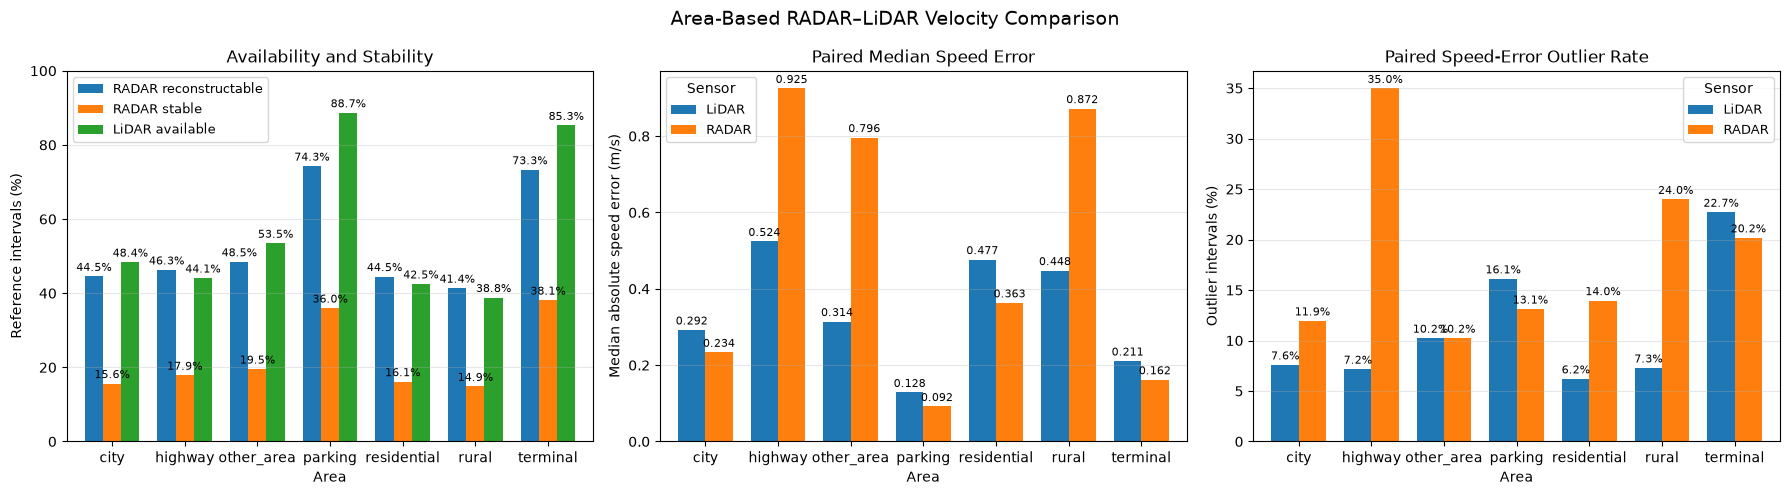

In [46]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Availability
availability_df = (
    area_summary
    .set_index("area")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
)

availability_df.plot(kind="bar", ax=axes[0], width=0.75)

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Area")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


# Figure 2: Paired median speed error
paired_speed_df = area_error_paired.pivot(
    index="area",
    columns="sensor",
    values="speed_err_median",
)

paired_speed_df.plot(kind="bar", ax=axes[1], width=0.75)

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].legend(title="Sensor", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)


# Figure 3: Paired outlier rate
paired_outlier_df = area_error_paired.pivot(
    index="area",
    columns="sensor",
    values="speed_err_outlier_pct",
)

paired_outlier_df.plot(kind="bar", ax=axes[2], width=0.75)

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Area")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].legend(title="Sensor", fontsize=9)
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Area-Based RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### 4.1 Area Availability
Sensor availability varies substantially by operational domain. In controlled, low-speed environments such as parking and terminal areas, LiDAR availability exceeds 85%, and RADAR stable reconstruction rates reach 35% to 38%. On highways, which represent the largest portion of data (147,262 intervals), LiDAR availability is 44.1%, RADAR stable rate is 17.9%, and paired availability is 16.3%. Rural environments demonstrate the lowest overall yield, with LiDAR at 38.8% and stable RADAR at 14.9%.

### 4.2 Area Speed Error and Outlier Distribution
Across paired intervals, LiDAR maintains a consistent median speed error between 0.13 and 0.52 m/s, with outlier rates bounded between 6% and 16%. RADAR performs accurately in urban and parking scenarios (median errors remaining below 0.30 m/s), but exhibits pronounced dispersion on open roads: highway intervals yield a RADAR median speed error of 0.925 m/s with an IQR of 12.66 m/s and a 35.0% outlier rate (compared to 7.2% for LiDAR); rural intervals produce a RADAR median error of 0.872 m/s and an outlier rate of 24.0%.

## 5. Weather

In [47]:
weather_lookup = condition_df[
    ["annotation_token", "scene_token", "weather"]
].rename(columns={
    "annotation_token": "start_annotation_token"
})

weather_df = comparison_df.merge(
    weather_lookup,
    on="start_annotation_token",
    how="left",
    validate="many_to_one",
)

if weather_df["weather"].isna().any():
    raise ValueError(
        "Some velocity intervals could not be matched to a weather condition."
    )

weather_df = add_velocity_analysis_columns(weather_df)

print("Weather conditions:", weather_df["weather"].unique())
print("Intervals:", len(weather_df))

Weather conditions: <StringArray>
['clear', 'rain', 'overcast', 'snow', 'other_weather', 'fog']
Length: 6, dtype: str
Intervals: 206040


In [48]:
weather_summary = availability_summary(weather_df, "weather")
weather_summary

,weather,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,clear,145,7090,110283,53028,21069,52931,19525,48.083567,19.104486,39.731840,47.995611,17.704451
1,fog,10,462,5715,2923,1371,1776,1066,51.146107,23.989501,46.903866,31.076115,18.652668
2,other_weather,1,10,331,213,56,260,56,64.350453,16.918429,26.291080,78.549849,16.918429
3,overcast,32,1572,27214,11541,4694,12007,4393,42.408319,17.248475,40.672385,44.120673,16.142427
4,rain,43,2430,50171,23575,8371,24645,8057,46.989297,16.684938,35.507953,49.122003,16.059078
5,snow,21,870,12326,6237,2618,4932,2127,50.600357,21.239656,41.975309,40.012981,17.256206


In [49]:
weather_error_all = error_summary(weather_df, "weather", both_sensors_only=False)
weather_error_all

,weather,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,clear,RADAR,145,4003,21069,0.865432,12.437952,46.955183,56.389536,7271,34.510418,15571,56.617327,163.016459
1,clear,LiDAR,145,5297,52931,0.278261,0.586417,1.605143,1.493453,5865,11.080463,38918,0.312868,1.304207
2,fog,RADAR,10,346,1371,7.658101,26.012739,63.115700,104.114175,267,19.474836,1371,68.632053,162.191260
3,fog,LiDAR,10,357,1776,0.493372,1.240493,1.145206,2.590111,179,10.078829,1772,0.364626,1.453798
4,other_weather,RADAR,1,3,56,0.147743,0.241069,0.178969,0.504734,1,1.785714,56,0.418732,1.363423
5,other_weather,LiDAR,1,7,260,0.140625,0.195690,0.230728,0.432457,13,5.000000,260,0.150362,0.470408
6,overcast,RADAR,32,807,4694,0.476630,0.904799,30.886353,7.273522,779,16.595654,2116,6.966389,121.353394
7,overcast,LiDAR,32,1092,12007,0.270372,0.560954,1.307644,1.419454,1302,10.843675,6042,0.571688,3.267715
8,rain,RADAR,43,1194,8371,0.327877,1.386911,39.733558,19.691677,1970,23.533628,6603,2.480249,119.016175
9,rain,LiDAR,43,1663,24645,0.187474,0.391969,4.857515,1.120866,3173,12.874822,20450,0.596159,2.580881


In [50]:
weather_error_paired = error_summary(weather_df, "weather", both_sensors_only=True)
weather_error_paired

,weather,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,clear,RADAR,145,3787,19525,0.800142,11.122800,38.216641,44.973905,6584,33.720871,14454,52.222960,163.973532
1,clear,LiDAR,145,3787,19525,0.500048,0.936920,2.398445,2.131612,1522,7.795134,14454,0.371709,1.353588
2,fog,RADAR,10,326,1066,5.400994,17.664458,32.285431,52.799994,158,14.821764,1066,67.027012,165.347950
3,fog,LiDAR,10,326,1066,0.863389,1.500466,1.198339,2.874007,29,2.720450,1066,0.500170,1.580335
4,other_weather,RADAR,1,3,56,0.147743,0.241069,0.178969,0.504734,1,1.785714,56,0.418732,1.363423
5,other_weather,LiDAR,1,3,56,0.229188,0.334965,0.373387,0.903690,6,10.714286,56,0.135007,0.332978
6,overcast,RADAR,32,750,4393,0.467046,0.873187,26.806286,6.147964,695,15.820624,2033,6.386402,119.717847
7,overcast,LiDAR,32,750,4393,0.385440,0.817965,1.869605,1.912503,423,9.628955,2033,0.690477,3.486289
8,rain,RADAR,43,1156,8057,0.307422,1.116539,32.334821,15.214178,1793,22.253941,6307,2.319236,117.793372
9,rain,LiDAR,43,1156,8057,0.285623,0.688877,8.326594,1.711694,964,11.964751,6307,0.556034,2.024304


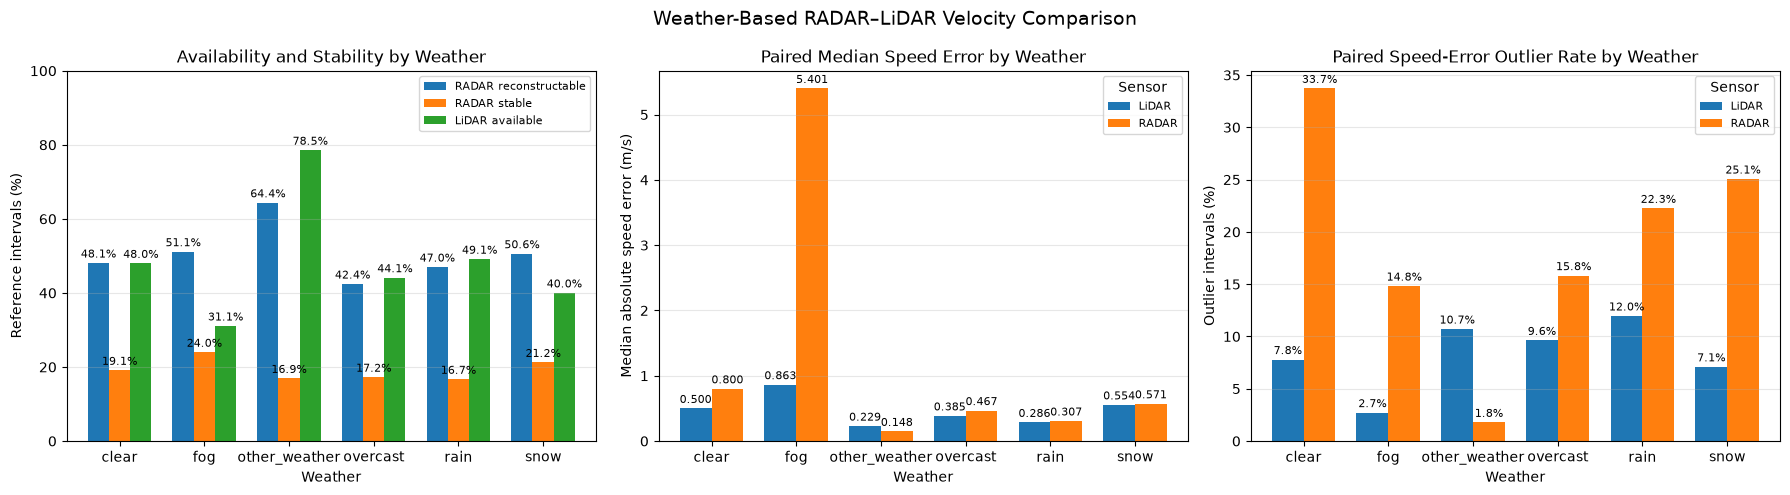

In [51]:
weather_order = weather_summary["weather"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Availability and stability
availability_df = (
    weather_summary
    .set_index("weather")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
    .reindex(weather_order)
)

availability_df.plot(kind="bar", ax=axes[0], width=0.75)

axes[0].set_title("Availability and Stability by Weather")
axes[0].set_xlabel("Weather")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


# 2. Paired median speed error
speed_df = (
    weather_error_paired
    .pivot(index="weather", columns="sensor", values="speed_err_median")
    .reindex(weather_order)
)

speed_df.plot(kind="bar", ax=axes[1], width=0.75)

axes[1].set_title("Paired Median Speed Error by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].legend(title="Sensor", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=2, fontsize=8)


# 3. Paired speed-error outlier rate
outlier_df = (
    weather_error_paired
    .pivot(index="weather", columns="sensor", values="speed_err_outlier_pct")
    .reindex(weather_order)
)

outlier_df.plot(kind="bar", ax=axes[2], width=0.75)

axes[2].set_title("Paired Speed-Error Outlier Rate by Weather")
axes[2].set_xlabel("Weather")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].legend(title="Sensor", fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Weather-Based RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### 5.1 Weather Availability
Clear and rain conditions form the majority of the dataset, with LiDAR availability around 48.0% and 49.1%, and RADAR stable rates at 19.1% and 16.7% respectively. In fog, optical degradation reduces LiDAR availability to 31.1%, whereas RADAR RF penetration yields a higher relative stable rate of 24.0% and a paired rate of 18.7%. Snow and overcast conditions show stable paired tracking rates between 16% and 17%.

### 5.2 Weather Speed Error Degradation
In rain, overcast, and snow conditions, performance between sensors remains well-bounded, with median speed errors below 0.6 m/s. Fog presents the most severe degradation for RADAR: while LiDAR median error increases moderately to 0.863 m/s (with an outlier rate of 2.7%), paired RADAR median error escalates to 5.401 m/s, accompanied by an IQR of 17.66 m/s and a P90 error of 52.80 m/s, reflecting heavy multipath reflections and doppler noise.

## 6. Visibility

In [52]:
condition_lookup = condition_df.set_index("annotation_token")
visibility_df = comparison_df.copy()

visibility_df["scene_token"] = (visibility_df["start_annotation_token"].map(condition_lookup["scene_token"]))
visibility_df["start_visibility"] = (visibility_df["start_annotation_token"].map(condition_lookup["visibility"]))
visibility_df["end_visibility"] = (visibility_df["end_annotation_token"].map(condition_lookup["visibility"]))

assert visibility_df[["scene_token", "start_visibility", "end_visibility"]].notna().all().all()

visibility_df["visibility"] = visibility_df[["start_visibility", "end_visibility"]].min(axis=1)

visibility_df = add_velocity_analysis_columns(visibility_df)

In [53]:
visibility_summary = availability_summary(visibility_df, "visibility")
visibility_summary

,visibility,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,1,250,9978,88554,22552,3896,17708,2940,25.466947,4.399575,17.275630,19.996838,3.320008
1,2,249,6294,22663,10079,3194,9847,2689,44.473371,14.093456,31.689652,43.449676,11.865155
2,3,249,5778,21796,12785,5676,12837,5055,58.657552,26.041476,44.395776,58.896128,23.192329
3,4,252,6452,73027,52101,25413,56159,24540,71.344845,34.799458,48.776415,76.901694,33.604009


In [54]:
visibility_error_all = error_summary(visibility_df, "visibility", both_sensors_only=False)
visibility_error_all

,visibility,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,1,RADAR,250,1430,3896,0.566321,6.449150,59.016705,54.025984,1152,29.568789,1851,61.406143,149.837646
1,1,LiDAR,250,2991,17708,0.244338,0.526794,3.303901,1.518463,2308,13.033657,11085,0.636227,3.063554
2,2,RADAR,249,1585,3194,0.814660,11.304625,56.128575,74.895472,1045,32.717595,1853,62.553738,155.562710
3,2,LiDAR,249,3090,9847,0.304991,0.672376,3.805176,1.718142,1152,11.698995,6412,0.553869,2.662851
4,3,RADAR,249,2528,5676,1.774915,17.783169,54.576819,81.514303,1878,33.086681,4194,65.944423,166.465540
5,3,LiDAR,249,3916,12837,0.325609,0.718868,3.814411,1.690738,1280,9.971177,9160,0.513768,1.928101
6,4,RADAR,252,4916,25413,0.517253,5.127834,37.410039,29.328482,7236,28.473616,19751,3.949195,153.423578
7,4,LiDAR,252,5897,56159,0.236133,0.498127,1.990308,1.317555,6543,11.650848,44439,0.322446,1.446792


In [55]:
visibility_error_paired = error_summary(visibility_df, "visibility", both_sensors_only=True)
visibility_error_paired

,visibility,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,1,RADAR,193,1015,2940,0.491465,3.776902,41.716974,31.819060,783,26.632653,1361,51.564730,150.734139
1,1,LiDAR,193,1015,2940,0.536295,1.331230,7.485749,3.463176,376,12.789116,1361,0.586072,2.677239
2,2,RADAR,221,1300,2689,0.734102,7.408017,40.531302,42.764589,805,29.936779,1485,60.103660,159.768979
3,2,LiDAR,221,1300,2689,0.507286,1.110291,7.080566,2.863566,309,11.491261,1485,0.516529,2.052377
4,3,RADAR,237,2252,5055,1.365651,14.552214,43.330814,56.221848,1713,33.887240,3653,65.068107,167.768407
5,3,LiDAR,237,2252,5055,0.527687,0.985113,5.966368,2.168315,356,7.042532,3653,0.505036,1.582757
6,4,RADAR,250,4787,24540,0.493899,4.207661,31.500803,25.040102,6736,27.449063,18979,3.601179,153.919322
7,4,LiDAR,250,4787,24540,0.413419,0.826253,2.916409,1.852729,1980,8.068460,18979,0.406282,1.597292


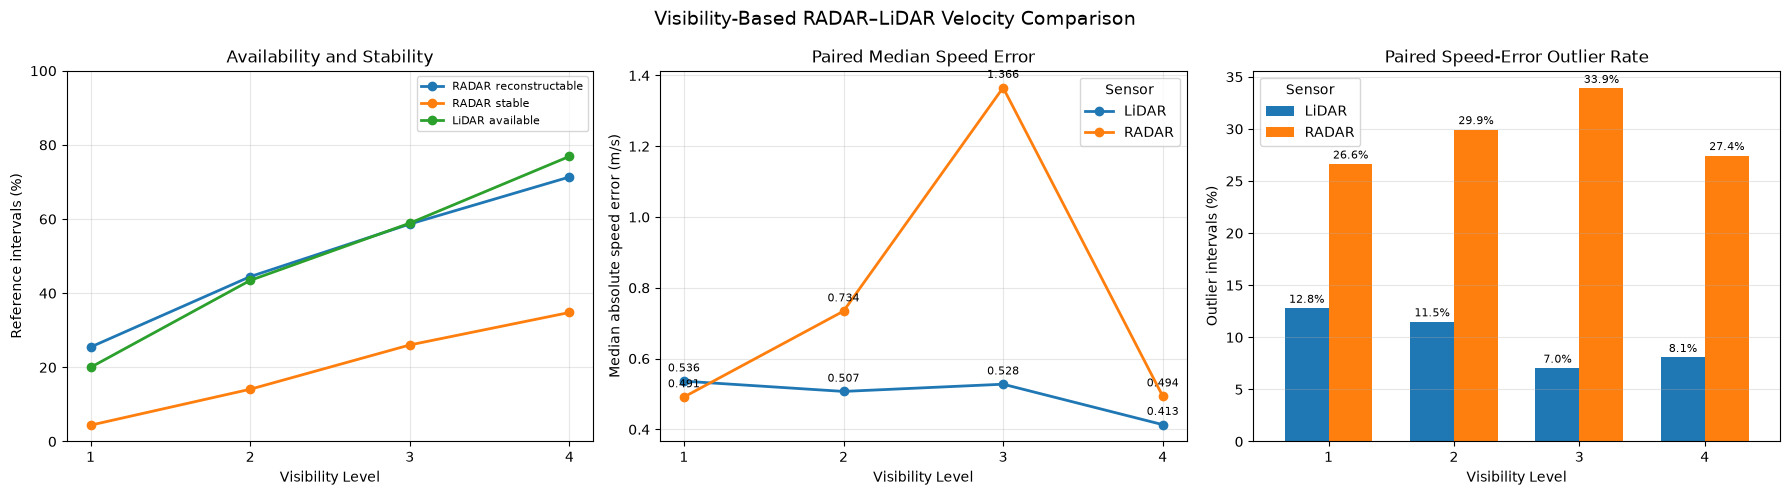

In [56]:
visibility_order = sorted(visibility_summary["visibility"].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# 1. Availability and stability trend
availability_df = (
    visibility_summary
    .set_index("visibility")[
        ["radar_reconstructable_pct", "radar_stable_pct", "lidar_pct"]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
    .reindex(visibility_order)
)

availability_df.plot(kind="line", marker="o", linewidth=2, ax=axes[0])

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Visibility Level")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_xticks(visibility_order)
axes[0].set_ylim(0, 100)
axes[0].legend(title="", fontsize=8)
axes[0].grid(alpha=0.3)


# 2. Paired median speed error trend
speed_df = (
    visibility_error_paired
    .pivot(
        index="visibility",
        columns="sensor",
        values="speed_err_median",
    )
    .reindex(visibility_order)
)

speed_df.plot(kind="line", marker="o", linewidth=2, ax=axes[1])

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Visibility Level")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].set_xticks(visibility_order)
axes[1].legend(title="Sensor")
axes[1].grid(alpha=0.3)

for line in axes[1].lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        axes[1].annotate(
            f"{y:.3f}",
            (x, y),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )


# 3. Paired outlier rate
outlier_df = (
    visibility_error_paired
    .pivot(
        index="visibility",
        columns="sensor",
        values="speed_err_outlier_pct",
    )
    .reindex(visibility_order)
)

outlier_df.plot(kind="bar", width=0.7, ax=axes[2])

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Visibility Level")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].legend(title="Sensor")
axes[2].grid(axis="y", alpha=0.3)
axes[2].tick_params(axis="x", rotation=0)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)


plt.suptitle("Visibility-Based RADAR–LiDAR Velocity Comparison", fontsize=14)

plt.tight_layout()
plt.show()

### 6.1 Visibility Availability Trends
Sensor reconstruction rates correlate positively with visibility levels (Level 1 to 4). At the lowest visibility (Level 1), LiDAR availability drops to 20.0% and RADAR stable rate to 4.4%, yielding a paired tracking rate of only 3.3%. At maximum visibility (Level 4), LiDAR availability reaches 76.9%, RADAR stable rate reaches 34.8%, and paired tracking increases to 33.6%.

### 6.2 Speed Error Across Visibility Levels
LiDAR speed accuracy remains resilient across all visibility gradations, with median error steady between 0.41 and 0.54 m/s and outlier rates remaining within 7% to 13%. RADAR median error is 0.491 m/s at Level 1, but exhibits broader variance at intermediate visibility bands (Level 2 and 3), where Level 3 median speed error reaches 1.366 m/s with an IQR of 14.55 m/s and an outlier rate of 33.9%.

## 7. Object Type

All available vehicle categories were retained in the analysis. Categories with limited scene, instance, or paired-interval coverage are reported but interpreted cautiously because their estimates may not generalise beyond the small observed sample.

In [57]:
condition_lookup = condition_df.set_index("annotation_token")
object_type_df = comparison_df.copy()

object_type_df["scene_token"] = (object_type_df["start_annotation_token"].map(condition_lookup["scene_token"]))
object_type_df["object_type"] = (object_type_df["start_annotation_token"].map(condition_lookup["object_type"]))

assert object_type_df[["scene_token", "object_type"]].notna().all().all()

object_type_df = add_velocity_analysis_columns(object_type_df)

In [58]:
object_type_summary = (
    availability_summary(object_type_df, "object_type")
    .sort_values("intervals", ascending=False,)
    .reset_index(drop=True)
)

object_type_summary

,object_type,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,vehicle.car,242,9345,146593,53572,21757,56508,19449,36.544719,14.841773,40.612633,38.547543,13.267346
1,vehicle.truck,237,1914,36573,26281,7183,24051,6916,71.859022,19.640172,27.331532,65.761627,18.910125
2,vehicle.trailer,213,965,17334,13745,6644,11936,6379,79.295027,38.329295,48.337577,68.858890,36.800508
3,vehicle.train,16,40,1526,1481,1352,1502,1346,97.051114,88.597641,91.289669,98.427261,88.204456
4,vehicle.bus.rigid,20,52,1424,1124,632,1035,561,78.932584,44.382022,56.227758,72.682584,39.396067
5,vehicle.bicycle,19,52,1044,300,150,536,144,28.735632,14.367816,50.000000,51.340996,13.793103
6,vehicle.construction,13,23,591,446,189,355,165,75.465313,31.979695,42.376682,60.067682,27.918782
7,vehicle.motorcycle,19,20,479,140,63,211,62,29.227557,13.152401,45.000000,44.050104,12.943633
8,vehicle.other,14,20,418,391,191,368,184,93.540670,45.693780,48.849105,88.038278,44.019139
9,vehicle.emergency.ambulance,2,2,50,33,15,46,15,66.000000,30.000000,45.454545,92.000000,30.000000


In [59]:
object_type_error_all = error_summary(object_type_df, "object_type", both_sensors_only=False)
object_type_error_all

,object_type,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,vehicle.bicycle,RADAR,19,28,150,0.140398,0.421496,0.729770,0.941168,26,17.333333,94,7.770819,24.729487
1,vehicle.bicycle,LiDAR,19,41,536,0.114700,0.163325,0.253964,0.397448,32,5.970149,306,0.640496,2.146605
2,vehicle.bus.rigid,RADAR,20,41,632,0.184410,0.618521,19.157170,3.259875,136,21.518987,110,3.834762,129.332909
3,vehicle.bus.rigid,LiDAR,20,48,1035,0.252377,0.692092,1.539595,1.919530,166,16.038647,230,0.771986,7.489237
4,vehicle.car,RADAR,242,4876,21757,0.704151,7.359755,50.798493,42.176388,6471,29.742152,17630,4.885201,151.290441
5,vehicle.car,LiDAR,242,6367,56508,0.233532,0.471495,0.662947,1.210550,6113,10.817937,43719,0.377118,1.735100
6,vehicle.construction,RADAR,13,18,189,0.274625,0.466155,2.059986,2.194693,27,14.285714,36,3.017714,96.530959
7,vehicle.construction,LiDAR,13,21,355,0.314221,0.565623,1.178782,1.485151,39,10.985915,59,1.452543,42.565900
8,vehicle.emergency.ambulance,RADAR,2,2,15,0.560092,7.559313,37.336543,51.101586,4,26.666667,15,2.805329,122.168740
9,vehicle.emergency.ambulance,LiDAR,2,2,46,0.175459,0.364468,0.657923,1.003101,7,15.217391,46,0.131903,0.464741


In [60]:
object_type_error_paired = error_summary(object_type_df, "object_type", both_sensors_only=True,)
object_type_error_paired

,object_type,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,vehicle.bicycle,RADAR,11,27,144,0.134089,0.403188,0.577404,0.894907,25,17.361111,93,7.667982,22.840391
1,vehicle.bicycle,LiDAR,11,27,144,0.109314,0.139723,0.257785,0.364494,10,6.944444,93,0.653055,1.857130
2,vehicle.bus.rigid,RADAR,16,39,561,0.180969,0.589949,20.127553,2.740537,118,21.033868,109,3.430381,129.802004
3,vehicle.bus.rigid,LiDAR,16,39,561,0.277629,0.827365,1.650552,2.386885,95,16.934046,109,0.760038,7.612401
4,vehicle.car,RADAR,235,4531,19449,0.617009,4.345912,35.753847,24.777509,5198,26.726310,15694,3.440912,152.402838
5,vehicle.car,LiDAR,235,4531,19449,0.443557,0.820492,0.821530,1.749478,1256,6.457916,15694,0.458783,1.539931
6,vehicle.construction,RADAR,7,14,165,0.246036,0.460395,2.145004,1.826481,23,13.939394,31,2.502199,86.927524
7,vehicle.construction,LiDAR,7,14,165,0.354410,0.615550,1.442647,2.041596,20,12.121212,31,0.976273,11.698136
8,vehicle.emergency.ambulance,RADAR,2,2,15,0.560092,7.559313,37.336543,51.101586,4,26.666667,15,2.805329,122.168740
9,vehicle.emergency.ambulance,LiDAR,2,2,15,0.758096,0.812183,0.947138,1.984389,1,6.666667,15,0.304874,0.879591


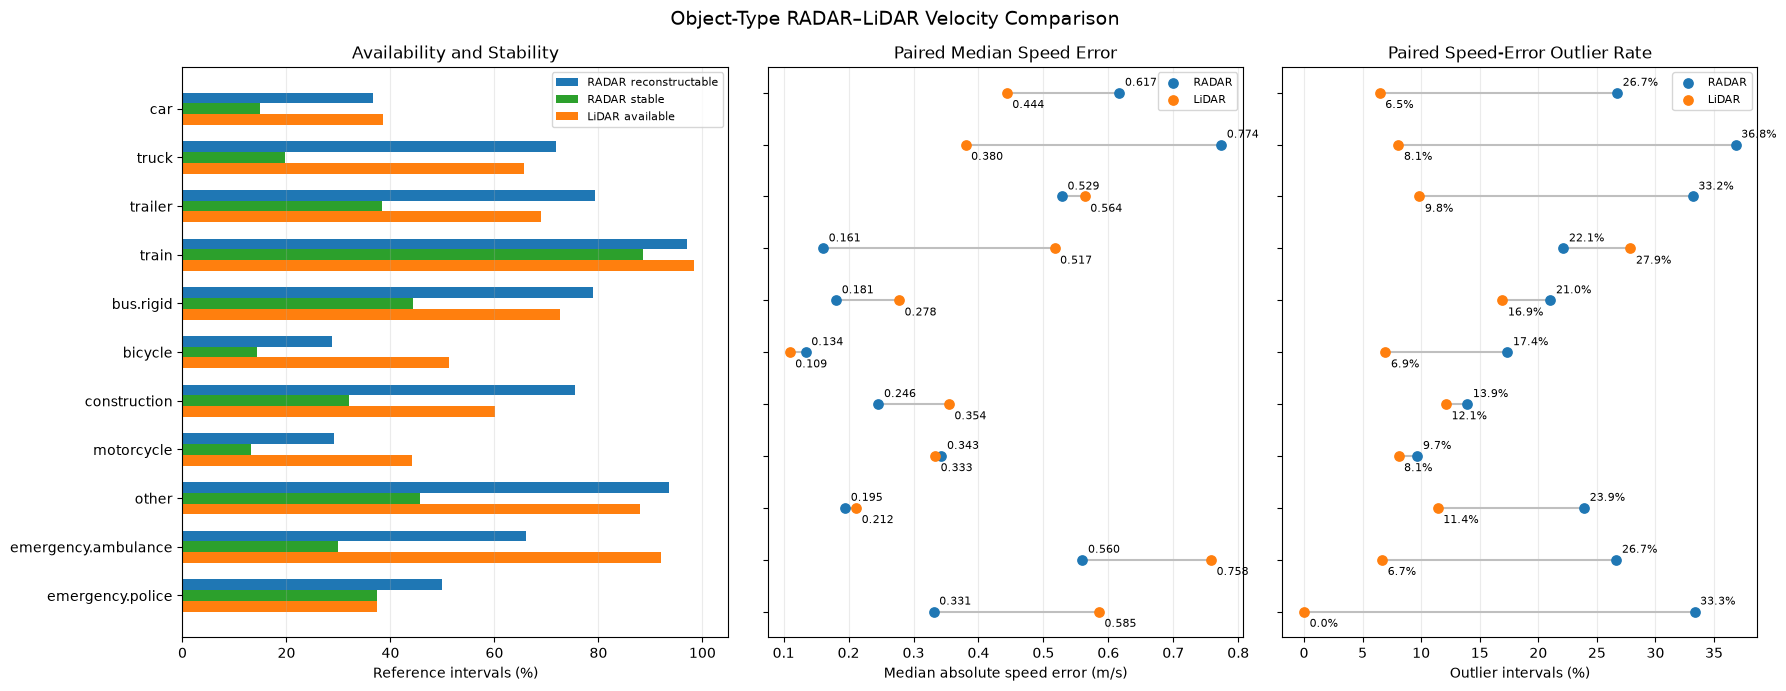

In [61]:
# Order by number of reference intervals
object_order = (object_type_summary.sort_values("intervals")["object_type"].tolist())

labels = [x.replace("vehicle.", "") for x in object_order]
y = np.arange(len(object_order))

radar_color = "C0"
lidar_color = "C1"
stable_color = "C2"

fig, axes = plt.subplots(1, 3, figsize=(18, 7), gridspec_kw={"width_ratios": [1.15, 1, 1]},)

# 1. Availability and stability
summary = (object_type_summary.set_index("object_type").reindex(object_order))

h = 0.22
axes[0].barh(
    y + h,
    summary["radar_reconstructable_pct"],
    height=h,
    label="RADAR reconstructable",
    color=radar_color,
)
axes[0].barh(
    y,
    summary["radar_stable_pct"],
    height=h,
    label="RADAR stable",
    color=stable_color,
)
axes[0].barh(
    y - h,
    summary["lidar_pct"],
    height=h,
    label="LiDAR available",
    color=lidar_color,
)

axes[0].set_title("Availability and Stability")
axes[0].set_xlabel("Reference intervals (%)")
axes[0].set_yticks(y)
axes[0].set_yticklabels(labels)
axes[0].set_xlim(0, 105)
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(fontsize=8)

# 2. Paired median speed error
speed = (
    object_type_error_paired
    .pivot(index="object_type", columns="sensor", values="speed_err_median")
    .reindex(object_order)
)

for i, row in enumerate(speed.itertuples()):
    axes[1].plot([row.RADAR, row.LiDAR], [i, i], color="0.75", linewidth=1.5)

axes[1].scatter(speed["RADAR"], y, label="RADAR", color=radar_color, s=45, zorder=3)
axes[1].scatter(speed["LiDAR"], y, label="LiDAR", color=lidar_color, s=45, zorder=3)

for i in range(len(speed)):
    axes[1].annotate(
        f'{speed.iloc[i]["RADAR"]:.3f}',
        (speed.iloc[i]["RADAR"], i),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )

    axes[1].annotate(
        f'{speed.iloc[i]["LiDAR"]:.3f}',
        (speed.iloc[i]["LiDAR"], i),
        xytext=(4, -11),
        textcoords="offset points",
        fontsize=8,
    )

axes[1].set_title("Paired Median Speed Error")
axes[1].set_xlabel("Median absolute speed error (m/s)")
axes[1].set_yticks(y)
axes[1].set_yticklabels([])
axes[1].grid(axis="x", alpha=0.25)
axes[1].legend(fontsize=8)

# 3. Paired outlier rate
outlier = (
    object_type_error_paired
    .pivot(index="object_type", columns="sensor", values="speed_err_outlier_pct")
    .reindex(object_order)
)

for i, row in enumerate(outlier.itertuples()):
    axes[2].plot([row.RADAR, row.LiDAR], [i, i], color="0.75", linewidth=1.5)

axes[2].scatter(outlier["RADAR"], y, label="RADAR", color=radar_color, s=45, zorder=3)
axes[2].scatter(outlier["LiDAR"], y, label="LiDAR", color=lidar_color, s=45, zorder=3)

for i in range(len(outlier)):
    axes[2].annotate(
        f'{outlier.iloc[i]["RADAR"]:.1f}%',
        (outlier.iloc[i]["RADAR"], i),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
    )

    axes[2].annotate(
        f'{outlier.iloc[i]["LiDAR"]:.1f}%',
        (outlier.iloc[i]["LiDAR"], i),
        xytext=(4, -11),
        textcoords="offset points",
        fontsize=8,
    )

axes[2].set_title("Paired Speed-Error Outlier Rate")
axes[2].set_xlabel("Outlier intervals (%)")
axes[2].set_yticks(y)
axes[2].set_yticklabels([])
axes[2].grid(axis="x", alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Object-Type RADAR–LiDAR Velocity Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### 7.1 Category-Specific Availability
Availability rates correlate strongly with target physical size and structure. Large commercial vehicles including trains, rigid buses, trailers, and trucks exhibit reconstructability between 71.9% and 96.9%, with stable RADAR tracking reaching up to 88.5% for trains. In contrast, passenger cars and two-wheelers show lower returns, with passenger cars yielding a LiDAR availability of 38.6% and a RADAR stable rate of 15.1%.

### 7.2 Velocity Error and Outlier Dispersion
LiDAR maintains bounded speed estimation across all vehicle classes, with median errors consistently between 0.212 and 0.585 m/s. RADAR performance diverges substantially based on target geometry. Commercial trucks, trailers, and cars suffer severe RADAR outlier dispersion (truck: 36.8%, trailer: 33.2%, car: 26.7%), with truck RADAR median error reaching 0.774 m/s compared to 0.380 m/s for LiDAR. For large continuous reflectors and emergency vehicles (trains, ambulances, and police units), RADAR achieves lower median errors than standalone LiDAR (train: 0.161 m/s vs 0.517 m/s; ambulance: 0.560 m/s vs 0.758 m/s; police: 0.331 m/s vs 0.585 m/s).

## 8. Distance

In [62]:
condition_lookup = condition_df.set_index("annotation_token")
distance_df = comparison_df.copy()
distance_df["scene_token"] = (distance_df["start_annotation_token"].map(condition_lookup["scene_token"]))
distance_df["start_distance_3d"] = (distance_df["start_annotation_token"].map(condition_lookup["distance_3d"]))
distance_df["end_distance_3d"] = (distance_df["end_annotation_token"].map(condition_lookup["distance_3d"]))

assert distance_df[["scene_token", "start_distance_3d", "end_distance_3d"]].notna().all().all()

distance_df["distance_3d"] = (distance_df["start_distance_3d"] + distance_df["end_distance_3d"]) / 2
distance_df["distance"] = create_distance_bands(distance_df["distance_3d"])
distance_df = add_velocity_analysis_columns(distance_df)

In [63]:
distance_summary = availability_summary(distance_df, "distance")
distance_summary

,distance,scenes,instances,intervals,radar_reconstructable_n,radar_stable_n,lidar_n,paired_n,radar_reconstructable_pct,radar_stable_pct,radar_stable_given_reconstructable_pct,lidar_pct,paired_pct
0,"[0.0, 25.0)",252,4642,25122,20746,16935,24165,16729,82.581005,67.411034,81.630194,96.190590,66.591036
1,"[25.0, 50.0)",252,7920,42396,28126,14937,33739,13623,66.341164,35.232097,53.107445,79.580621,32.132748
2,"[50.0, 75.0)",250,8292,35527,18731,4958,19276,3915,52.723281,13.955583,26.469489,54.257325,11.019788
3,"[75.0, 100.0)",249,7906,29192,12930,1054,10338,760,44.292957,3.610578,8.151585,35.413812,2.603453
4,"[100.0, 125.0)",246,7115,22260,7588,208,4085,139,34.088050,0.934412,2.741170,18.351303,0.624438
5,"[125.0, 150.0)",238,6455,17845,4858,76,2272,54,27.223312,0.425890,1.564430,12.731858,0.302606
6,"[150.0, 175.0)",237,5766,14861,3174,8,1480,3,21.357917,0.053832,0.252048,9.958953,0.020187
7,"[175.0, 200.0)",234,5026,12537,1345,3,788,1,10.728244,0.023929,0.223048,6.285395,0.007976
8,"[200.0, 225.0)",221,2442,6188,19,0,405,0,0.307046,0.000000,0.000000,6.544926,0.000000
9,"[225.0, 250.0)",25,28,112,0,0,3,0,0.000000,0.000000,NaN,2.678571,0.000000


In [64]:
distance_error_all = error_summary(distance_df, "distance", both_sensors_only=False)
distance_error_all

,distance,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,"[0.0, 25.0)",RADAR,252,3720,16935,0.308481,0.863469,13.616220,6.733936,2975,17.567169,11916,1.614935,140.888612
1,"[0.0, 25.0)",LiDAR,252,4464,24165,0.310652,0.760124,1.541465,1.846082,2865,11.855990,17579,0.375946,1.737783
2,"[25.0, 50.0)",RADAR,252,5578,14937,1.398948,15.280430,40.059833,55.816725,5111,34.217045,11224,63.021060,166.976666
3,"[25.0, 50.0)",LiDAR,252,6971,33739,0.241076,0.524705,1.583365,1.387220,4122,12.217315,24349,0.395905,1.773599
4,"[50.0, 75.0)",RADAR,250,2886,4958,4.913582,57.869972,80.466717,159.848683,1653,33.340056,3752,66.810153,128.869612
5,"[50.0, 75.0)",LiDAR,250,4880,19276,0.229265,0.430798,3.346194,1.081156,1881,9.758249,13999,0.373841,2.059824
6,"[75.0, 100.0)",RADAR,249,691,1054,1.167624,46.298641,89.319718,160.408878,406,38.519924,640,72.552876,127.375147
7,"[75.0, 100.0)",LiDAR,249,2899,10338,0.222527,0.436387,5.703342,1.162503,1143,11.056297,8228,0.365045,1.670950
8,"[100.0, 125.0)",RADAR,246,80,208,0.597428,2.235516,58.432447,12.100324,45,21.634615,79,67.259989,111.835551
9,"[100.0, 125.0)",LiDAR,246,1464,4085,0.312695,0.619126,2.004862,1.771537,507,12.411261,3175,0.525921,2.542968


In [65]:
distance_error_paired = error_summary(distance_df, "distance", both_sensors_only=True)
distance_error_paired

,distance,sensor,scenes,instances,intervals,speed_err_median,speed_err_iqr,speed_err_std,speed_err_p90,speed_err_outlier_n,speed_err_outlier_pct,moving_intervals,dir_err_median,dir_err_p90
0,"[0.0, 25.0)",RADAR,252,3667,16729,0.301461,0.828366,13.157700,6.161694,2873,17.173770,11767,1.583310,140.037786
1,"[0.0, 25.0)",LiDAR,252,3667,16729,0.400399,0.919321,1.769771,2.073777,1614,9.647917,11767,0.405040,1.818612
2,"[25.0, 50.0)",RADAR,250,5186,13623,1.222775,13.487893,32.559809,43.496790,4671,34.287602,10220,62.281176,168.018347
3,"[25.0, 50.0)",LiDAR,250,5186,13623,0.449328,0.885198,2.336427,1.940368,1061,7.788299,10220,0.471390,1.548472
4,"[50.0, 75.0)",RADAR,222,2250,3915,4.240976,50.990214,66.160918,130.627039,1330,33.971903,2964,65.727216,127.858579
5,"[50.0, 75.0)",LiDAR,222,2250,3915,0.549572,0.805512,7.259094,2.135095,355,9.067688,2964,0.429164,1.348073
6,"[75.0, 100.0)",RADAR,126,473,760,1.046078,40.385786,72.207193,126.280769,290,38.157895,452,72.706944,133.187039
7,"[75.0, 100.0)",LiDAR,126,473,760,0.504801,0.994210,20.704653,3.539361,110,14.473684,452,0.491462,1.991676
8,"[100.0, 125.0)",RADAR,21,38,139,0.561427,2.379657,45.448421,9.317886,32,23.021583,48,84.056579,111.981986
9,"[100.0, 125.0)",LiDAR,21,38,139,1.474859,4.359647,8.347642,9.522403,17,12.230216,48,15.705919,179.507179


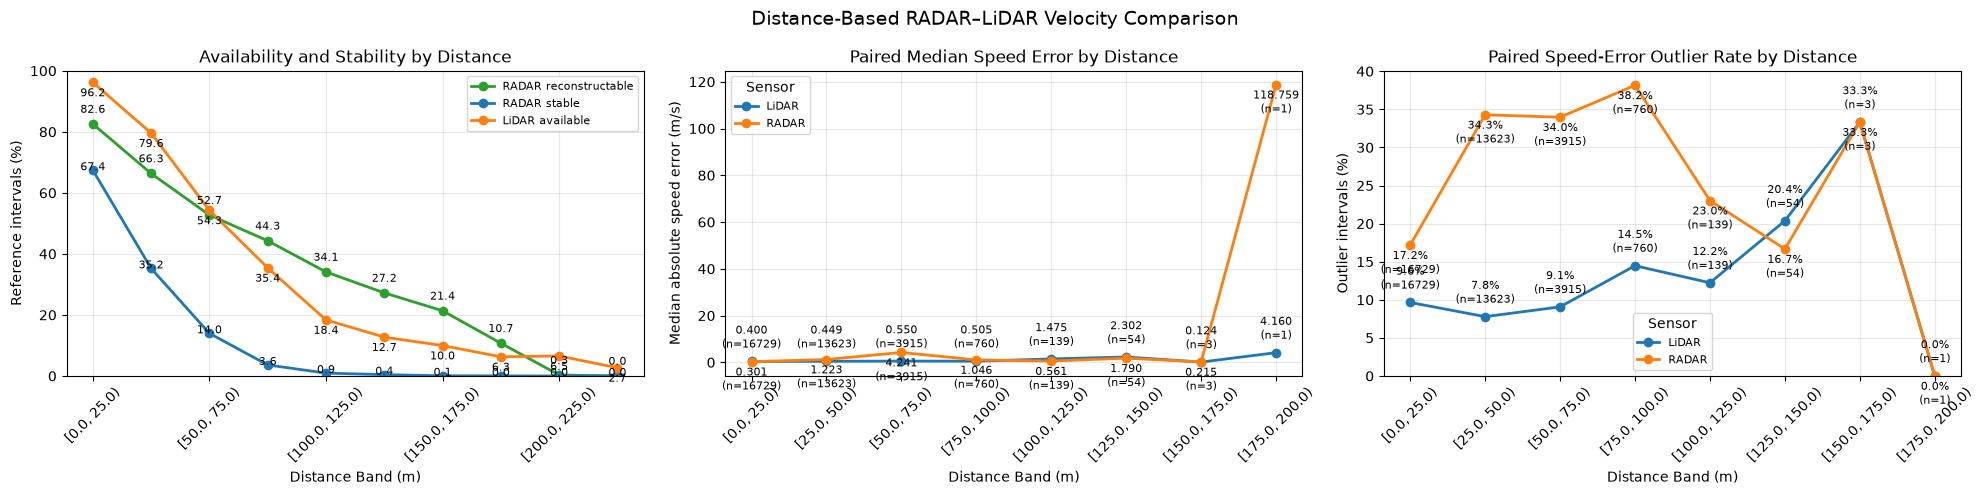

In [66]:
radar_color = "C0"
lidar_color = "C1"
reconstructable_color = "C2"

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Availability / Stability
availability_df = (
    distance_summary
    .copy()
    .set_index("distance")[
        [
            "radar_reconstructable_pct",
            "radar_stable_pct",
            "lidar_pct",
        ]
    ]
    .rename(columns={
        "radar_reconstructable_pct": "RADAR reconstructable",
        "radar_stable_pct": "RADAR stable",
        "lidar_pct": "LiDAR available",
    })
)

availability_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[0],
    color=[reconstructable_color, radar_color, lidar_color],
)

axes[0].set_title("Availability and Stability by Distance")
axes[0].set_xlabel("Distance Band (m)")
axes[0].set_ylabel("Reference intervals (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="", fontsize=8)

for line_idx, line in enumerate(axes[0].lines):
    offset = 8 if line_idx == 0 else (0 if line_idx == 1 else -10)
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        axes[0].annotate(
            f"{y:.1f}",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

# 2) Paired Median Speed Error (only bins with paired_n > 0)
paired_bins = distance_summary.loc[distance_summary["paired_n"] > 0, "distance"].tolist()

speed_df = (
    distance_error_paired
    .pivot(index="distance", columns="sensor", values="speed_err_median")
    .reindex(paired_bins)
)

speed_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color=[radar_color, lidar_color],
)

axes[1].set_title("Paired Median Speed Error by Distance")
axes[1].set_xlabel("Distance Band (m)")
axes[1].set_ylabel("Median absolute speed error (m/s)")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Sensor", fontsize=8)

paired_n_lookup = (
    distance_summary
    .set_index("distance")["paired_n"]
    .to_dict()
)

for line_idx, line in enumerate(axes[1].lines):
    offset = 10 if line_idx == 0 else -20
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        label = speed_df.index[x]
        n = paired_n_lookup[label]
        axes[1].annotate(
            f"{y:.3f}\n(n={n})",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

# 3) Paired Outlier Rate (only bins with paired_n > 0)
outlier_df = (
    distance_error_paired
    .pivot(
        index="distance",
        columns="sensor",
        values="speed_err_outlier_pct",
    )
    .reindex(paired_bins)
)

outlier_df.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[2],
    color=[radar_color, lidar_color],
)

axes[2].set_title("Paired Speed-Error Outlier Rate by Distance")
axes[2].set_xlabel("Distance Band (m)")
axes[2].set_ylabel("Outlier intervals (%)")
axes[2].set_ylim(bottom=0)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Sensor", fontsize=8)

for line_idx, line in enumerate(axes[2].lines):
    offset = 10 if line_idx == 0 else -20
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        label = outlier_df.index[x]
        n = paired_n_lookup[label]
        axes[2].annotate(
            f"{y:.1f}%\n(n={n})",
            (x, y),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

plt.suptitle(
    "Distance-Based RADAR–LiDAR Velocity Comparison",
    fontsize=14,
)
plt.tight_layout()
plt.show()

### 8.1 Distance Decay and Tracking Availability
Detection coverage drops sharply as target distance increases. Within the near range [0.0, 25.0) m, LiDAR and RADAR stable availability reach 96.2% and 67.4% respectively. Beyond 75.0 m, RADAR stable tracking falls below 3.6% and drops to nearly zero beyond 100.0 m, while LiDAR availability remains at 18.4% at [100.0, 125.0) m before tapering off.   

### 8.2 Speed Error and Outlier Divergence Across Range Bands
LiDAR demonstrates stable speed tracking across all distance bands up to 175 m, with median errors contained below 0.6 m/s and outlier rates remaining under 15% in densely populated intervals. RADAR speed error remains reasonably bounded up to 150 m (median error below 1.8 m/s), but suffers high outlier contamination (34% to 38% between 25 and 100 m). In the extreme distance band [175.0, 200.0) m, severe signal sparsity and multipath effects cause RADAR median speed error to diverge drastically to 118.759 m/s, demonstrating that un-gated long-range radar returns will introduce destructive contamination into fusion pipelines.

## 9. Cross-Condition Interaction Analysis

Research Question:
How do multiple operating conditions jointly affect RADAR and LiDAR velocity performance?

In [67]:
cross_condition_df = build_cross_condition_df(comparison_df, condition_df)
paired_long_df = build_paired_long_df(cross_condition_df)
model_df = prepare_interaction_model_df(paired_long_df)
interaction_model = fit_sensor_condition_model(model_df, clustered=False)

print("Observations:", int(interaction_model.nobs))
print("R-squared:", round(interaction_model.rsquared, 3))
print("Adjusted R-squared:", round(interaction_model.rsquared_adj, 3))

Observations: 70448
R-squared: 0.308
Adjusted R-squared: 0.308


In [68]:
coef_table = pd.DataFrame({
    "coefficient": interaction_model.params,
    "std_error": interaction_model.bse,
    "p_value": interaction_model.pvalues,
    "ci_low": interaction_model.conf_int()[0],
    "ci_high": interaction_model.conf_int()[1],
})

display(coef_table)

,coefficient,std_error,p_value,ci_low,ci_high
Intercept,0.361440,0.018380,7.347577e-86,0.325415,0.397465
"C(sensor, Treatment(reference=""LiDAR""))[T.RADAR]",-0.347063,0.025993,1.291495e-40,-0.398010,-0.296117
"C(area, Treatment(reference=""city""))[T.highway]",0.188995,0.018173,2.599869e-25,0.153375,0.224615
"C(area, Treatment(reference=""city""))[T.other_area]",0.037477,0.084063,6.557298e-01,-0.127287,0.202240
"C(area, Treatment(reference=""city""))[T.parking]",-0.199530,0.037189,8.107005e-08,-0.272420,-0.126640
"C(area, Treatment(reference=""city""))[T.residential]",0.131068,0.040205,1.114788e-03,0.052266,0.209871
"C(area, Treatment(reference=""city""))[T.rural]",0.162946,0.027121,1.886757e-09,0.109788,0.216103
"C(area, Treatment(reference=""city""))[T.terminal]",-0.109443,0.026688,4.121436e-05,-0.161752,-0.057135
"C(weather, Treatment(reference=""clear""))[T.fog]",0.136952,0.029365,3.109556e-06,0.079397,0.194506
"C(weather, Treatment(reference=""clear""))[T.other_weather]",-0.263409,0.123659,3.316535e-02,-0.505781,-0.021037


In [69]:
condition_interaction_model = fit_condition_interaction_model(model_df, clustered=False)

print("Observations:", int(condition_interaction_model.nobs))
print("Parameters:", len(condition_interaction_model.params))
print("R-squared:", round(condition_interaction_model.rsquared, 3))
print("Adjusted R-squared:", round(condition_interaction_model.rsquared_adj, 3))

Observations: 70448
Parameters: 279
R-squared: 0.338
Adjusted R-squared: 0.336


c:\Users\mindfulness\Desktop\CITS3200\src\condition\cross_condition.py:128: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return model.fit()


In [70]:
# 这个代码后面可以删掉，这是为了进行一个验证
# 如果Rank deficiency: 0，那model就没有问题，如果不是0，就根据数据再删掉某些无法估计的interaction
# X = condition_interaction_model.model.exog
# rank = np.linalg.matrix_rank(X)

# print("Design matrix columns:", X.shape[1])
# print("Design matrix rank:", rank)
# print("Rank deficiency:", X.shape[1] - rank)

### Visualisation

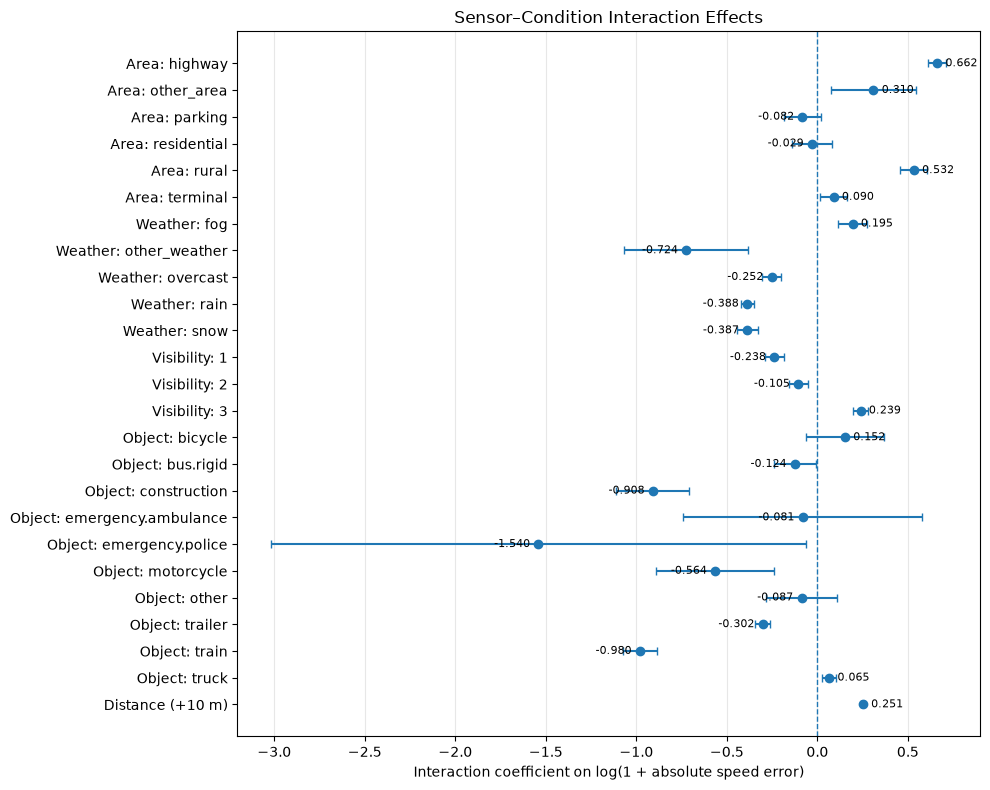

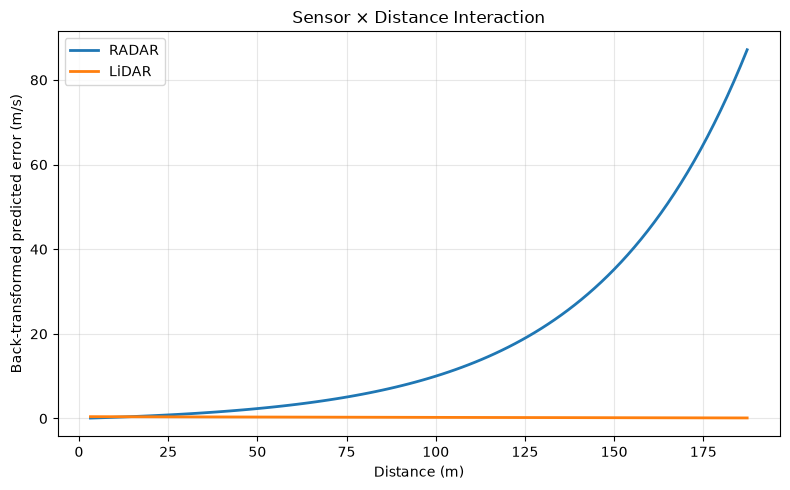

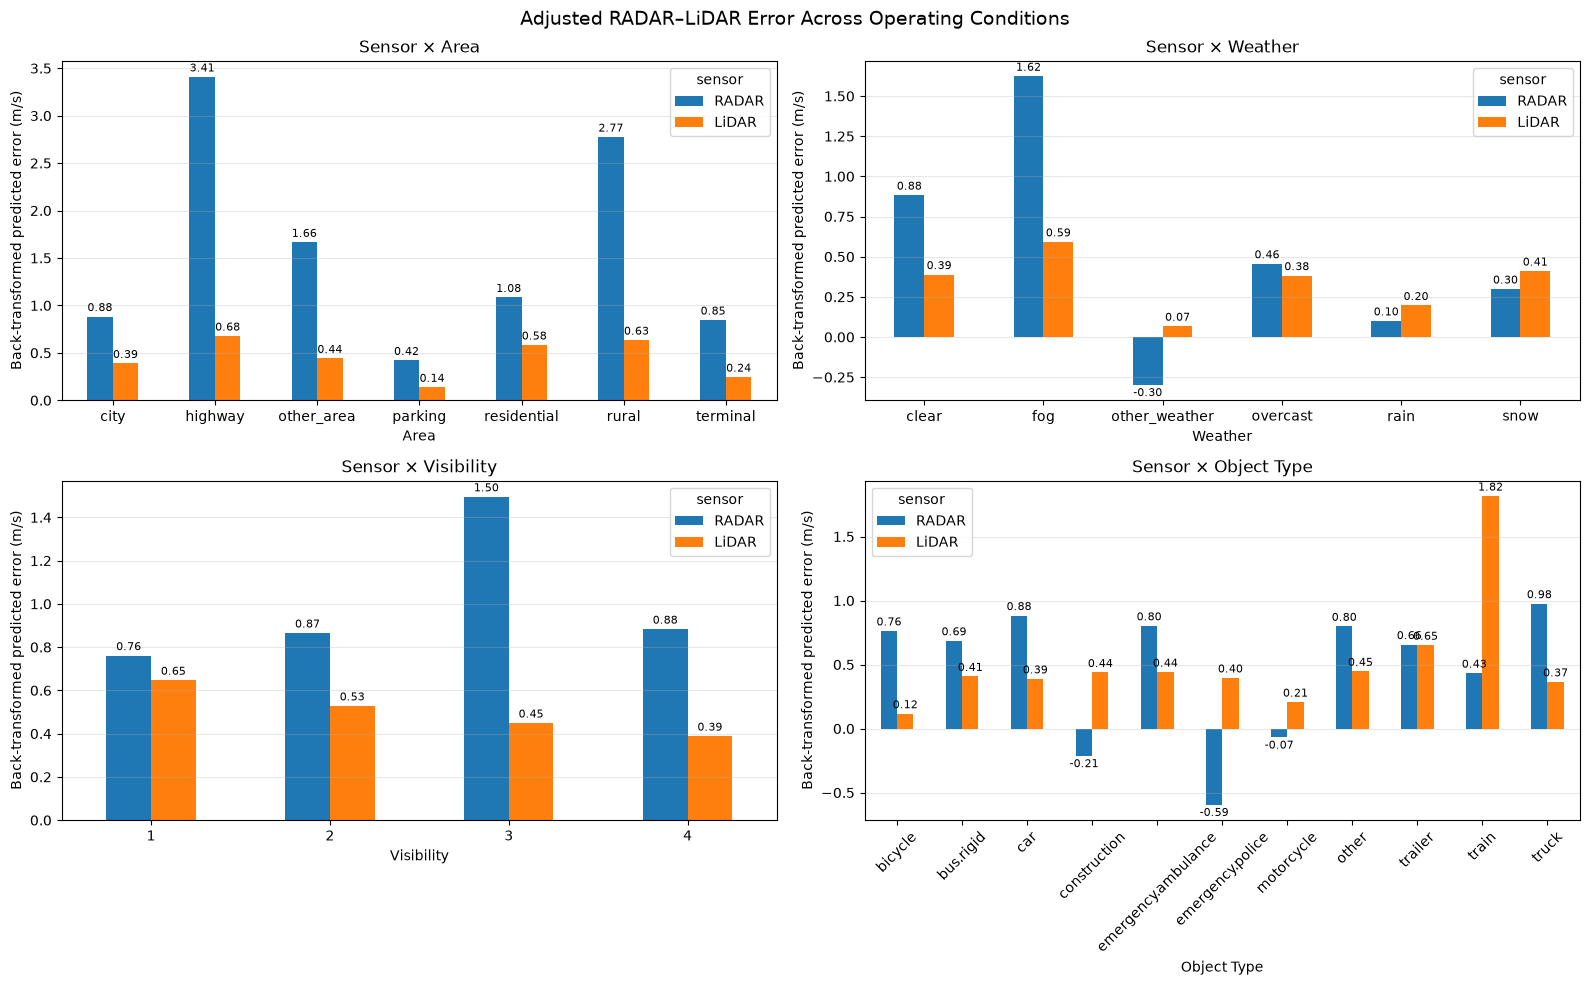

Condition–condition interaction plot skipped: the current model is rank-deficient.


In [71]:
plot_sensor_interaction_coefficients(interaction_model)
plot_sensor_distance_interaction(interaction_model, model_df)
plot_sensor_condition_grid(interaction_model, model_df)
plot_condition_interactions(condition_interaction_model)

### 9.1 Distance Interaction and Exponential Divergence
The log-linear interaction model reveals systematic divergence between sensors across operating ranges, with the distance interaction term demonstrating dominant exponential degradation for RADAR (+0.251 coefficient per +10 m). As range increases, back-transformed predicted speed error for LiDAR remains flat and tightly bounded below 0.5 m/s across the entire 0 to 185 m range. In contrast, RADAR error exhibits steep non-linear divergence, remaining under 5.0 m/s within 75 m, climbing past 20.0 m/s beyond 125 m, and accelerating to over 85.0 m/s at 185 m. This confirms that radar velocity uncertainty grows exponentially with range due to beam spreading, multipath interference, and weak radial projection constraints.

### 9.2 Operational Domain and Weather Interactions
Operational area and weather conditions significantly amplify RADAR error while LiDAR remains largely invariant. High-speed and open environments yield strong positive error interaction coefficients for RADAR, led by highway (+0.662, predicted error 3.41 m/s vs 0.68 m/s for LiDAR) and rural domains (+0.532, predicted error 2.77 m/s vs 0.63 m/s for LiDAR). Similarly, fog conditions exacerbate RADAR degradation (+0.195 interaction coefficient, predicted error 1.62 m/s vs 0.59 m/s for LiDAR), whereas rain and overcast show negative interaction effects (-0.388 and -0.252) where both sensors maintain low baseline errors below 0.5 m/s.

### 9.3 Object Category Specificity
Physical target properties heavily influence relative sensor accuracy. Large geometric structures and emergency vehicles yield negative interaction coefficients favoring RADAR over LiDAR, such as police vehicles (-1.540), trains (-0.980, predicted error 0.43 m/s vs 1.82 m/s for LiDAR), and construction machinery (-0.908). Conversely, standard passenger cars and smaller dynamic targets yield positive coefficients where RADAR underperforms LiDAR (car predicted error 0.88 m/s vs 0.39 m/s; truck predicted error 0.98 m/s vs 0.37 m/s).

## 10. RADAR–LiDAR Complementarity and Fusion

This section investigates whether combining RADAR and LiDAR can improve velocity
coverage and velocity accuracy.

Two aspects are considered:

1. **Sensor complementarity:** whether combining the availability of both sensors
   increases the number of reference intervals for which a velocity estimate is
   available.

2. **Velocity fusion:** whether a simple vector-average fusion of RADAR and LiDAR
   improves velocity accuracy when both sensors provide a valid estimate.

Each reference interval is classified as **Both**, **RADAR only**, **LiDAR only**
or **Neither** according to stable RADAR velocity availability and LiDAR velocity
availability.

Combined availability represents intervals for which at least one sensor
provides a valid velocity estimate.

For intervals where both sensors provide a valid velocity estimate, a simple
baseline fusion is constructed by averaging the RADAR and LiDAR horizontal
velocity vectors:

$$
v_{x,\mathrm{fused}} =
\frac{v_{x,\mathrm{RADAR}} + v_{x,\mathrm{LiDAR}}}{2},
\qquad
v_{y,\mathrm{fused}} =
\frac{v_{y,\mathrm{RADAR}} + v_{y,\mathrm{LiDAR}}}{2}
$$

No model training or optimisation is used. The purpose is to establish a simple,
reproducible fusion baseline before considering more complex weighting methods.

In [72]:
fusion_df = add_fusion_columns(cross_condition_df)
complementarity = complementarity_summary(fusion_df)
fusion_accuracy = fusion_accuracy_summary(fusion_df)

display(complementarity)
display(fusion_accuracy)

,metric,intervals,pct_reference
0,RADAR stable,38179,18.5
1,LiDAR available,96551,46.9
2,Both,35224,17.1
3,RADAR only,2955,1.4
4,LiDAR only,61327,29.8
5,Neither,106534,51.7
6,Combined available,99506,48.3
7,Incremental vs RADAR,61327,29.8
8,Incremental vs LiDAR,2955,1.4


,sensor,intervals,speed_err_median,speed_err_iqr,speed_err_p90,dir_err_median,dir_err_p90
0,RADAR,35224,0.572,6.052,30.469,6.253,156.950
1,LiDAR,35224,0.443,0.903,2.071,0.433,1.654
2,Fused,35224,0.556,8.036,21.697,2.887,102.121


In [ ]:
fusion_by_area = fusion_condition_summary(fusion_df, "area")
fusion_by_weather = fusion_condition_summary(fusion_df, "weather")
fusion_by_visibility = fusion_condition_summary(fusion_df, "visibility")
fusion_by_object = fusion_condition_summary(fusion_df, "object_type")
fusion_by_distance = fusion_condition_summary(fusion_df, "distance")

In [ ]:
# display(fusion_by_area)
# display(fusion_by_weather)
# display(fusion_by_visibility)
# display(fusion_by_object)
# display(fusion_by_distance)

In [ ]:
fusion_gain_area = fusion_gain_summary(fusion_by_area, "area")
fusion_gain_weather = fusion_gain_summary(fusion_by_weather, "weather")
fusion_gain_visibility = fusion_gain_summary(fusion_by_visibility, "visibility")
fusion_gain_object = fusion_gain_summary(fusion_by_object, "object_type")
fusion_gain_distance = fusion_gain_summary(fusion_by_distance, "distance")

In [ ]:
# display(fusion_gain_area)
# display(fusion_gain_weather)
# display(fusion_gain_visibility)
# display(fusion_gain_object)
# display(fusion_gain_distance)

### Visualisation

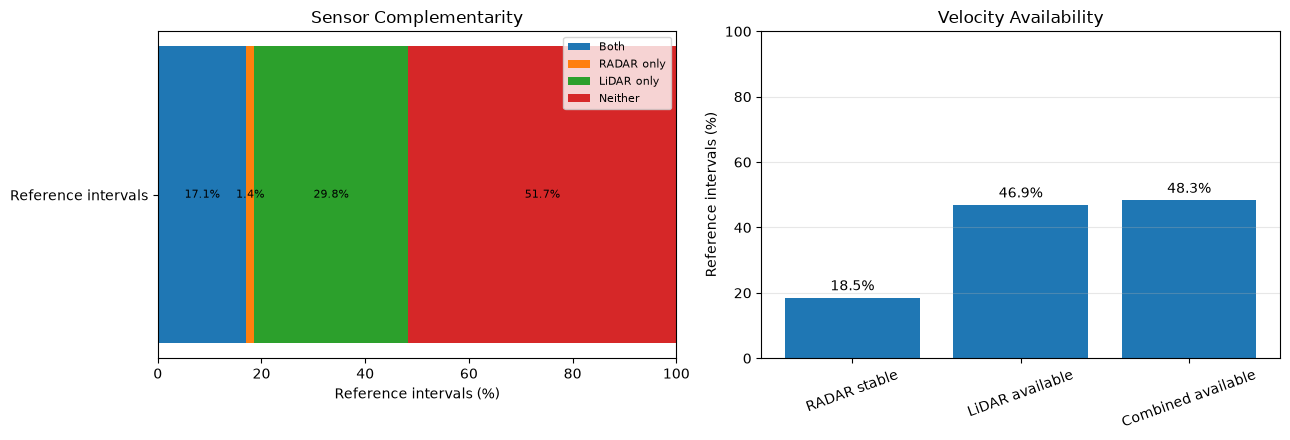

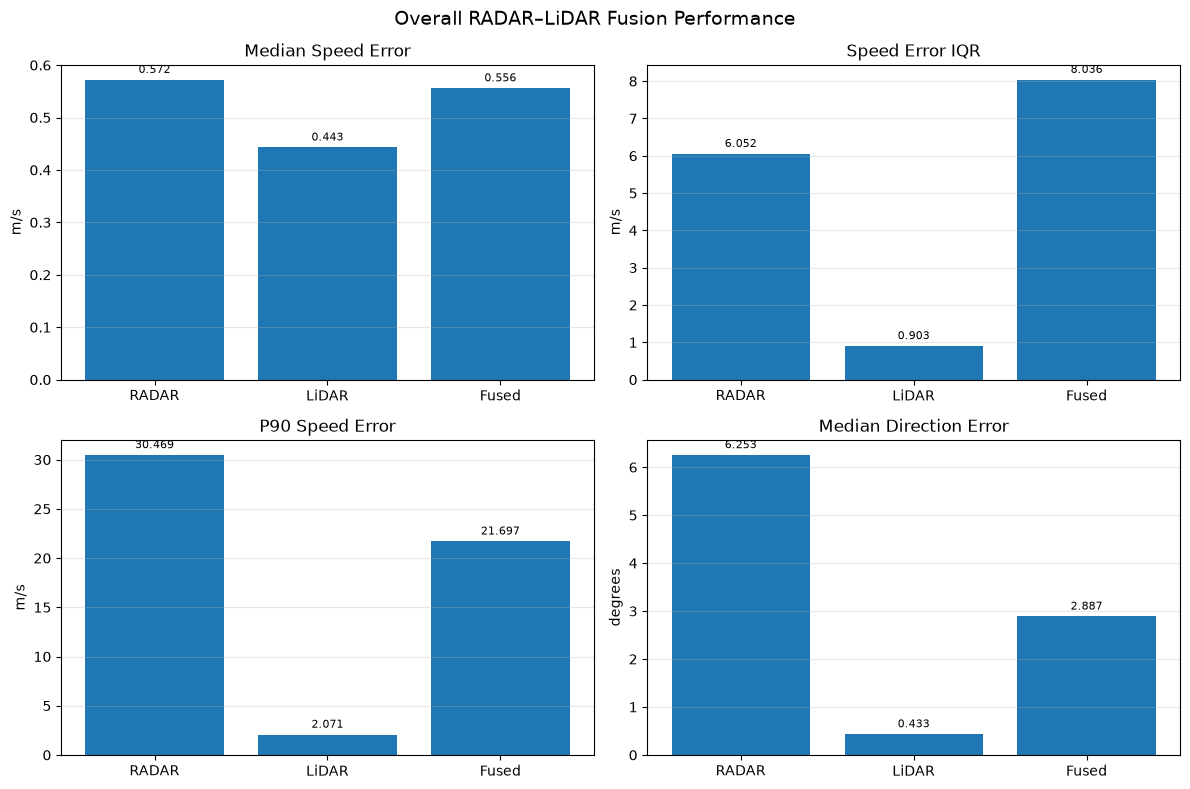

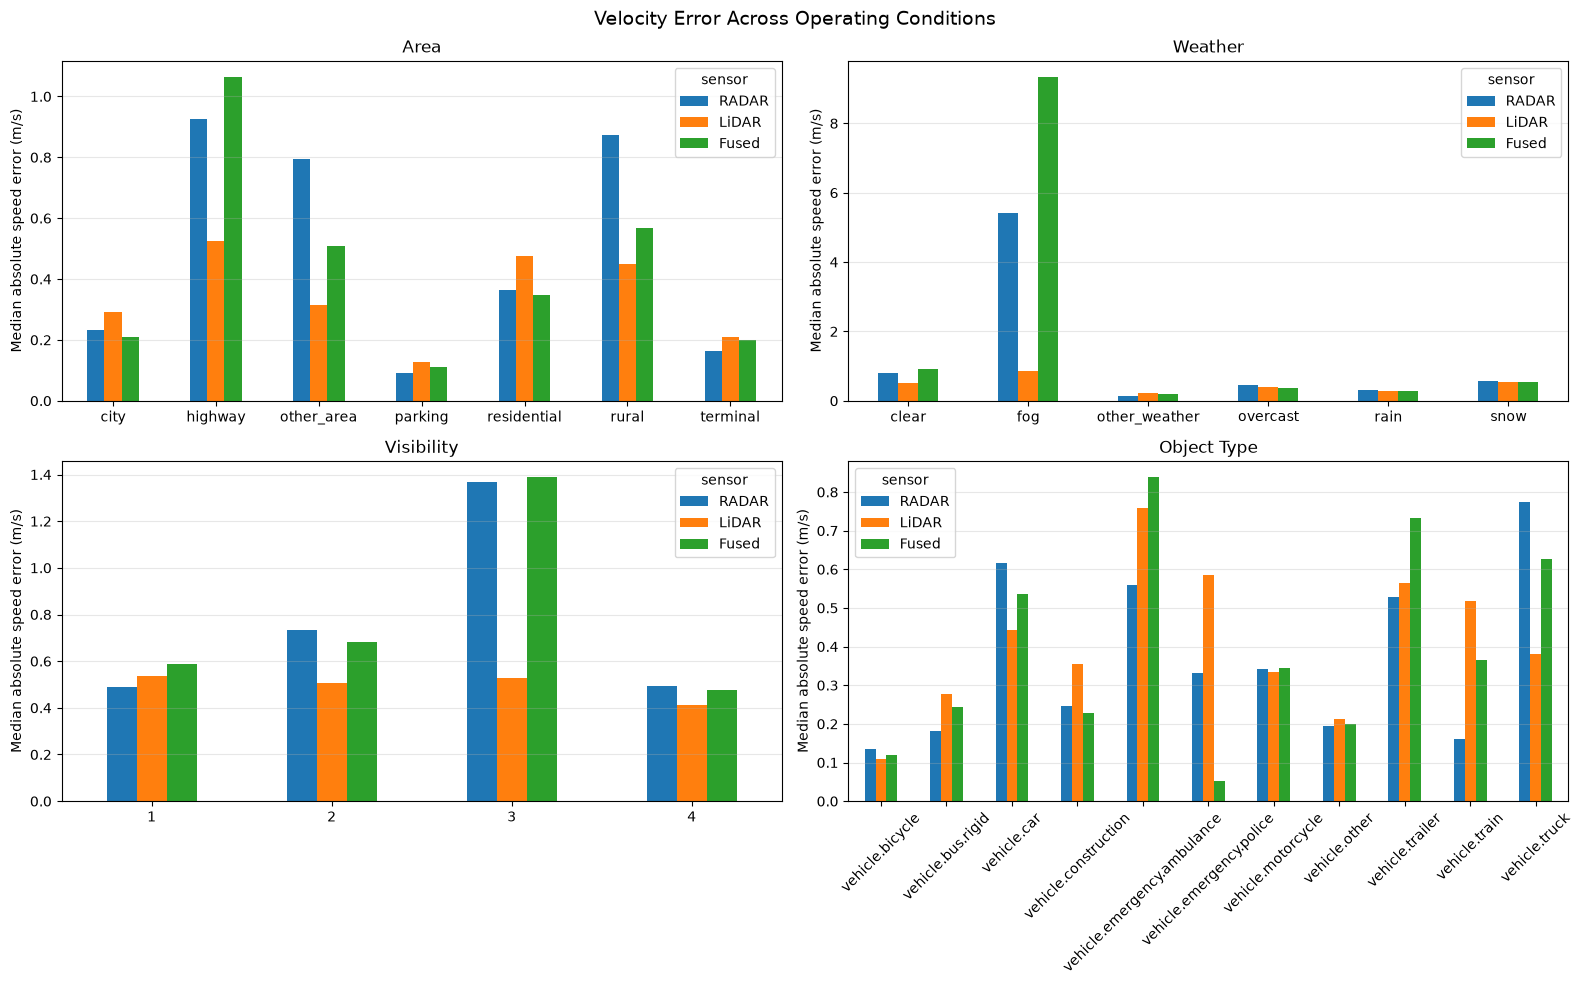

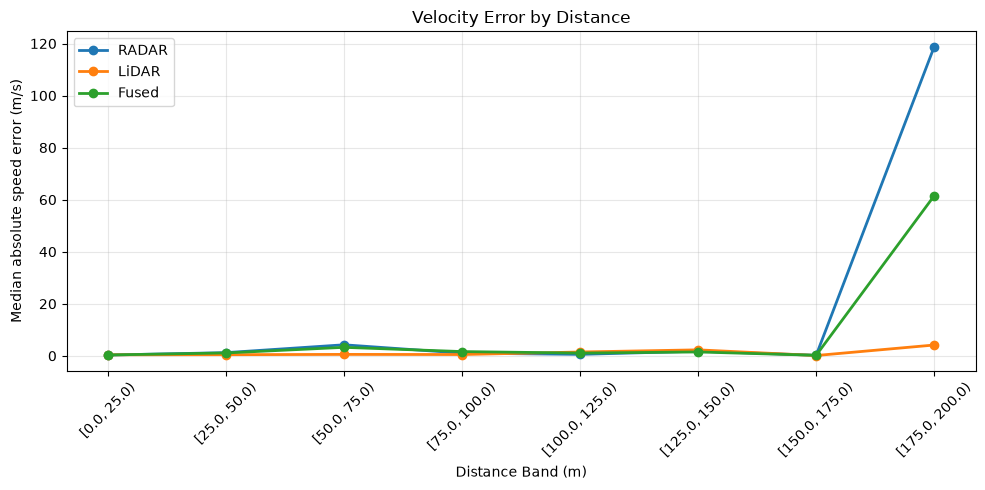

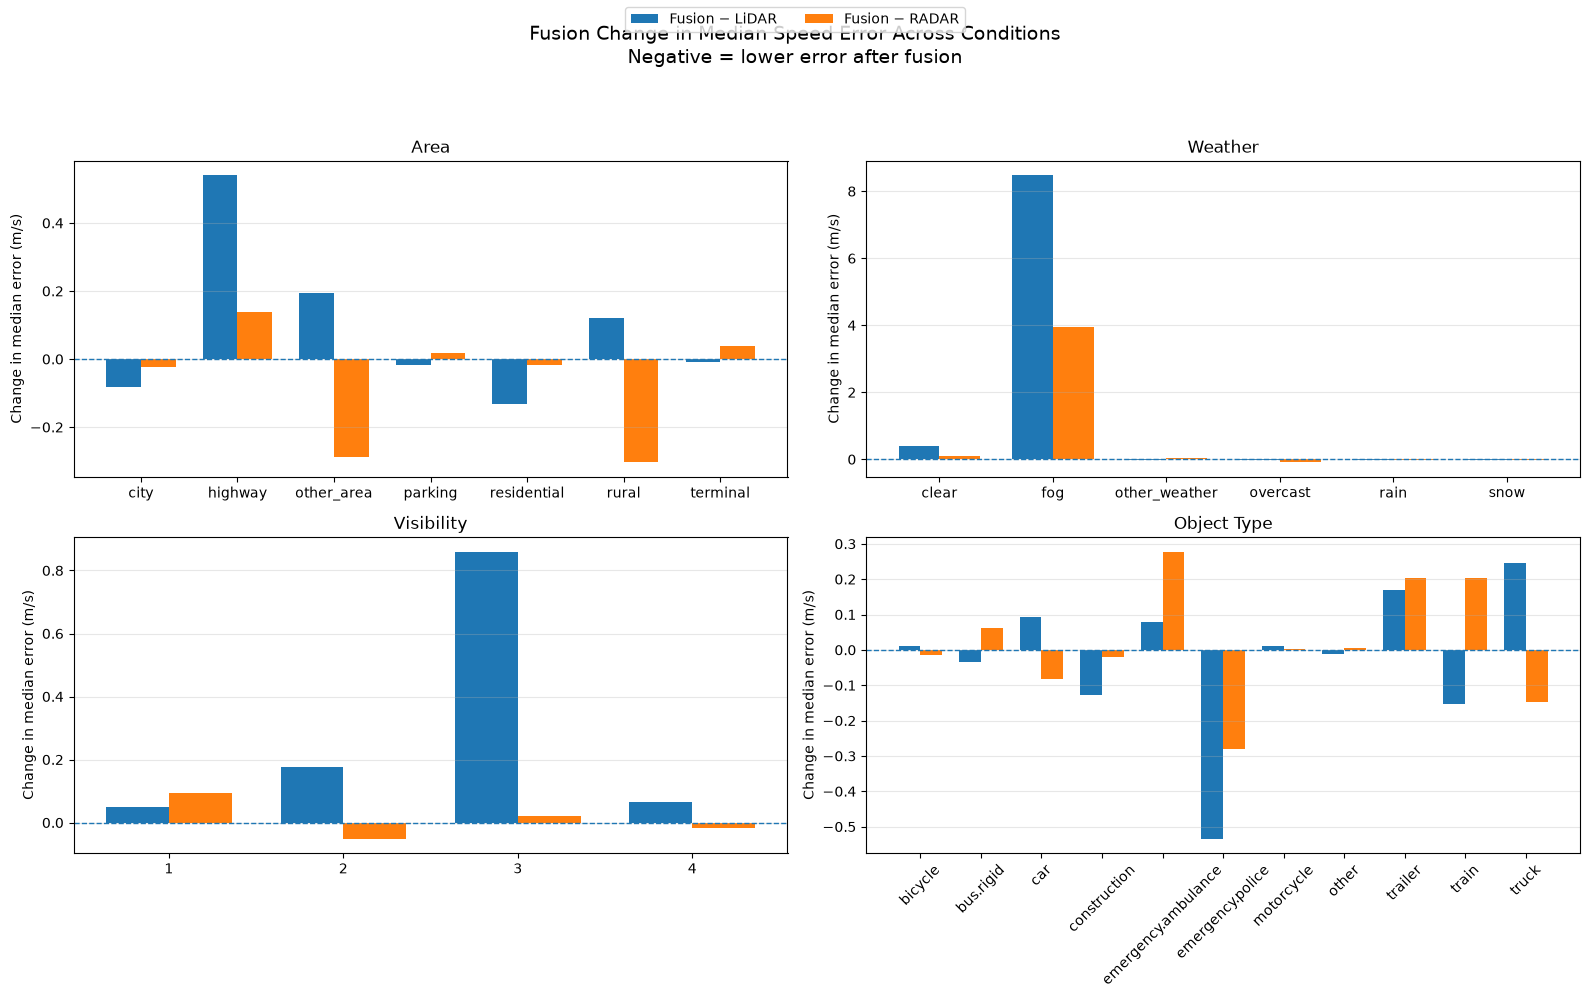

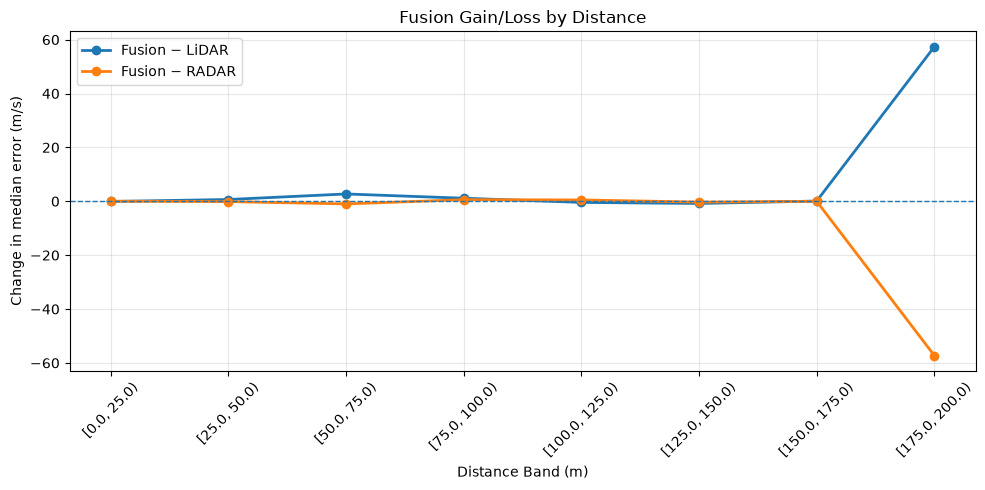

In [ ]:
plot_fusion_complementarity(complementarity)
plot_overall_fusion_accuracy(fusion_accuracy)

plot_fusion_condition_grid(
    fusion_by_area,
    fusion_by_weather,
    fusion_by_visibility,
    fusion_by_object,
)

plot_fusion_distance(fusion_by_distance)

plot_fusion_gain_grid(
    fusion_gain_area,
    fusion_gain_weather,
    fusion_gain_visibility,
    fusion_gain_object,
)

plot_fusion_gain_distance(fusion_gain_distance)

### 10.1 Sensor Complementarity and Combined Availability
Sensor overlap analysis indicates that simultaneous dual-sensor tracking occurs in only 17.1% of valid reference intervals. LiDAR-only tracking covers 29.8% of intervals, while RADAR-only tracking accounts for 1.4%, leaving 51.7% of target intervals unobserved by both modalities. While RADAR stable availability stands at 18.5% and LiDAR availability at 46.9%, naive joint availability yields 48.3%. This represents only a modest absolute coverage expansion (+1.4%) over standalone LiDAR, showing that RADAR offers limited independent spatial expansion within the current verification pipeline.

### 10.2 Overall Baseline Fusion Accuracy
On paired evaluation intervals, simple fusion demonstrates mixed estimation fidelity compared to standalone baselines. The fused median speed error settles at 0.556 m/s, which improves upon standalone RADAR (0.572 m/s) but slightly degrades compared to standalone LiDAR (0.443 m/s). For error dispersion, fusion successfully constrains extreme tail error, reducing the P90 speed error to 21.697 m/s (down from 30.469 m/s for RADAR, though still above 2.071 m/s for LiDAR). Directional estimation shows a similar pattern, with fused median direction error reaching 2.887 degrees, effectively halving RADAR error (6.253 degrees) while trailing high-precision LiDAR (0.433 degrees).

### 10.3 Condition-Specific Fusion Gain and Degradation
Fusion performance diverges sharply across operational conditions. Under adverse weather and dynamic road conditions, naive fusion induces severe negative gain where error increases relative to standalone LiDAR: in fog, fusion median error increases by +8.50 m/s compared to LiDAR; on highways, it increases by +0.54 m/s; and at Visibility Level 3, it increases by +0.86 m/s. Conversely, positive fusion gains emerge in specific structured categories and lower-speed areas. In rural environments, fusion reduces error by -0.31 m/s relative to RADAR. For emergency ambulances, fusion achieves its strongest positive synergy, reducing median error by -0.53 m/s relative to LiDAR and by -0.28 m/s relative to RADAR.

### 10.4 Range-Dependent Fusion Divergence
Across distances up to 150.0 m, fusion delta metrics remain tightly centered around zero, indicating that fusion neither significantly improves nor degrades tracking in the near-to-mid range. However, in the extreme distance band [175.0, 200.0) m, the severe divergence of un-gated RADAR measurements heavily corrupts the joint state. Fusion error increases by +57.24 m/s relative to standalone LiDAR, while reducing error by -57.36 m/s relative to standalone RADAR. This confirms that a strict distance gating threshold (cutting RADAR fusion beyond 150 m) is required to prevent catastrophic state divergence in autonomous driving pipelines.

## 11. Key Findings
Sensor Availability and Complementary Coverage

Out of 206,128 total reference intervals, LiDAR demonstrated an availability rate of 46.9% (96,551 intervals), while RADAR achieved a stable reconstruction rate of 18.5% (38,179 intervals). Combined fusion availability reached 48.3% (99,506 intervals). Although the majority of validated tracking (29.8%) relied solely on LiDAR, RADAR provided an incremental coverage gain of 1.4% (2,955 intervals) when LiDAR was unavailable. Availability degrades steeply with distance: within 0 ~ 25 m, LiDAR availability was 96.2% and RADAR reconstructability was 82.6%; beyond 100 m, LiDAR dropped below 18.4% and RADAR stable rate fell below 1.0%.   

Accuracy and Dispersion Discrepancy

LiDAR demonstrates consistent accuracy and high heading fidelity: Across all paired observations, LiDAR speed error median remained at 0.443 m/s (IQR: 0.903 m/s, P90: 2.071 m/s), with a median direction error of only 0.433° (P90: 1.654°). Across visibility levels 1 through 4, LiDAR speed error remained stable between 0.41 ~ 0.54 m/s.
RADAR exhibits heavy-tail outlier profiles: While RADAR maintained a comparable overall median speed error of 0.572 m/s, its IQR reached 6.052 m/s, P90 reached 30.469 m/s, and median direction error was 6.253°. On highways, the RADAR speed outlier rate climbed to 35.0% (compared to 7.2% for LiDAR); under fog conditions, paired RADAR median error surged to 5.401 m/s.

Distance Degradation and Long-Range Divergence

Regression results indicate a statistically significant positive interaction coefficient for RADAR × distance_10m (+0.251, p < 0.001), verifying a super-linear growth in RADAR error over distance. In the 175 ~ 200 m interval, sparse point returns and multipath reflections caused RADAR median error to spike to 118.76 m/s (n=1).   Fusion Performance and Degradation Patterns
Positive Gains: In rural settings and for specific categories (e.g., ambulances), fusion mitigated RADAR noise, reducing ambulance median speed error by approximately 0.53 m/s relative to LiDAR alone. Overall P90 error was trimmed from 30.47 m/s (RADAR) down to 21.70 m/s (Fused).
Negative Interference: In the absence of residual threshold gating, unvalidated RADAR Doppler outliers severely corrupted fusion estimates under fog (> +8.5 m/s degradation relative to LiDAR), on highways, and at extended distances (175 ~ 200 m, where fused error rose to 61.4 m/s vs. 4.16 m/s for pure LiDAR).

## 12. Limitations
Severe Class Imbalance in Tail Scenarios: Certain operating regimes suffer from extreme sample sparsity (e.g., only 1 paired interval at 175 ~ 200 m, and under 10 instances for emergency vehicles), causing specific metrics to be sensitive to individual sample anomalies. 
  
Lack of Outlier Gating in Current Pipeline: Raw RADAR Doppler observations were injected into the fusion module without chi-square or Mahalanobis distance validation gating, allowing multipath artifacts to degrade the joint state.   

Confounding Environmental Variables: Strong collinearity exists between weather conditions, visibility, and operational areas (e.g., highway intervals correlate with higher velocities and distances; precipitation correlates with lower visibility), complicating pure isolated causal attribution in the regression model.  

## 13. Conclusion
LiDAR serves as the high-precision baseline for ground-truth velocity and orientation estimation; RADAR provides marginal coverage extensions (+1.4%) and penetration utility in edge conditions. Without statistical gating, uniform fusion fails to outperform standalone LiDAR under normal conditions and introduces significant performance degradation in fog, at high vehicle speeds, and at ranges exceeding 100 m. Robust deployment requires covariance-adaptive weighting alongside a strict distance-cutoff policy that falls back to standalone LiDAR tracking when target distance exceeds 100 m.